In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.insert(0, "/home/nboley/src/fragmentomics_tools/projects/")

In [3]:
import os

import itertools
import pandas as pd
import seaborn

from fragments_h5 import FragmentsH5

from fragmentomics_tools.dataframe import RegionDataFrame, SampleAndRegionDataFrame
from fragmentomics_tools.dataframe import Region
from fragmentomics_tools.fragment_array import RegionFragmentArray, merge_fragment_arrays

from ibd.lib import load_ibd_sample_df, make_single_strand_bndry
from ibd.data import build_ctcf_binding_sites

# Sample Prep

In [4]:
sdf = load_ibd_sample_df()
# sdf = sdf.query("DIAGNOSIS == 'Ulcerative Colitis'")
#sdf = sdf.query("DIAGNOSIS == 'Crohn\\'s Disease'")
sdf

,sample_id,label,frag_h5,DIAGNOSIS,ENDO_CATEGORY,Cluster,SITE_NUMBER
365,RD-36403,0,<fragments_h5.fragments_h5.FragmentsH5 object ...,Asymptomatic,Asymptomatic,NaN,Site_4
364,RD-36402,0,<fragments_h5.fragments_h5.FragmentsH5 object ...,Asymptomatic,Asymptomatic,NaN,Site_8
337,RD-36063,0,<fragments_h5.fragments_h5.FragmentsH5 object ...,Asymptomatic,Asymptomatic,NaN,Site_8
338,RD-36064,0,<fragments_h5.fragments_h5.FragmentsH5 object ...,Asymptomatic,Asymptomatic,NaN,Site_4
339,RD-36065,0,<fragments_h5.fragments_h5.FragmentsH5 object ...,Asymptomatic,Asymptomatic,NaN,Site_7
...,...,...,...,...,...,...,...
320,RD-50565,4,<fragments_h5.fragments_h5.FragmentsH5 object ...,Crohn's Disease,Severe,Patient Group 1,Site_13
321,RD-50591,4,<fragments_h5.fragments_h5.FragmentsH5 object ...,Crohn's Disease,Severe,Patient Group 1,Site_13
322,RD-50592,4,<fragments_h5.fragments_h5.FragmentsH5 object ...,Crohn's Disease,Severe,Patient Group 2,Site_16
333,RD-56149,4,<fragments_h5.fragments_h5.FragmentsH5 object ...,Crohn's Disease,Severe,Patient Group 6,Site_7


In [7]:
sdf.label.value_counts()

label
1    102
2     78
3     64
4     33
0     28
Name: count, dtype: int64

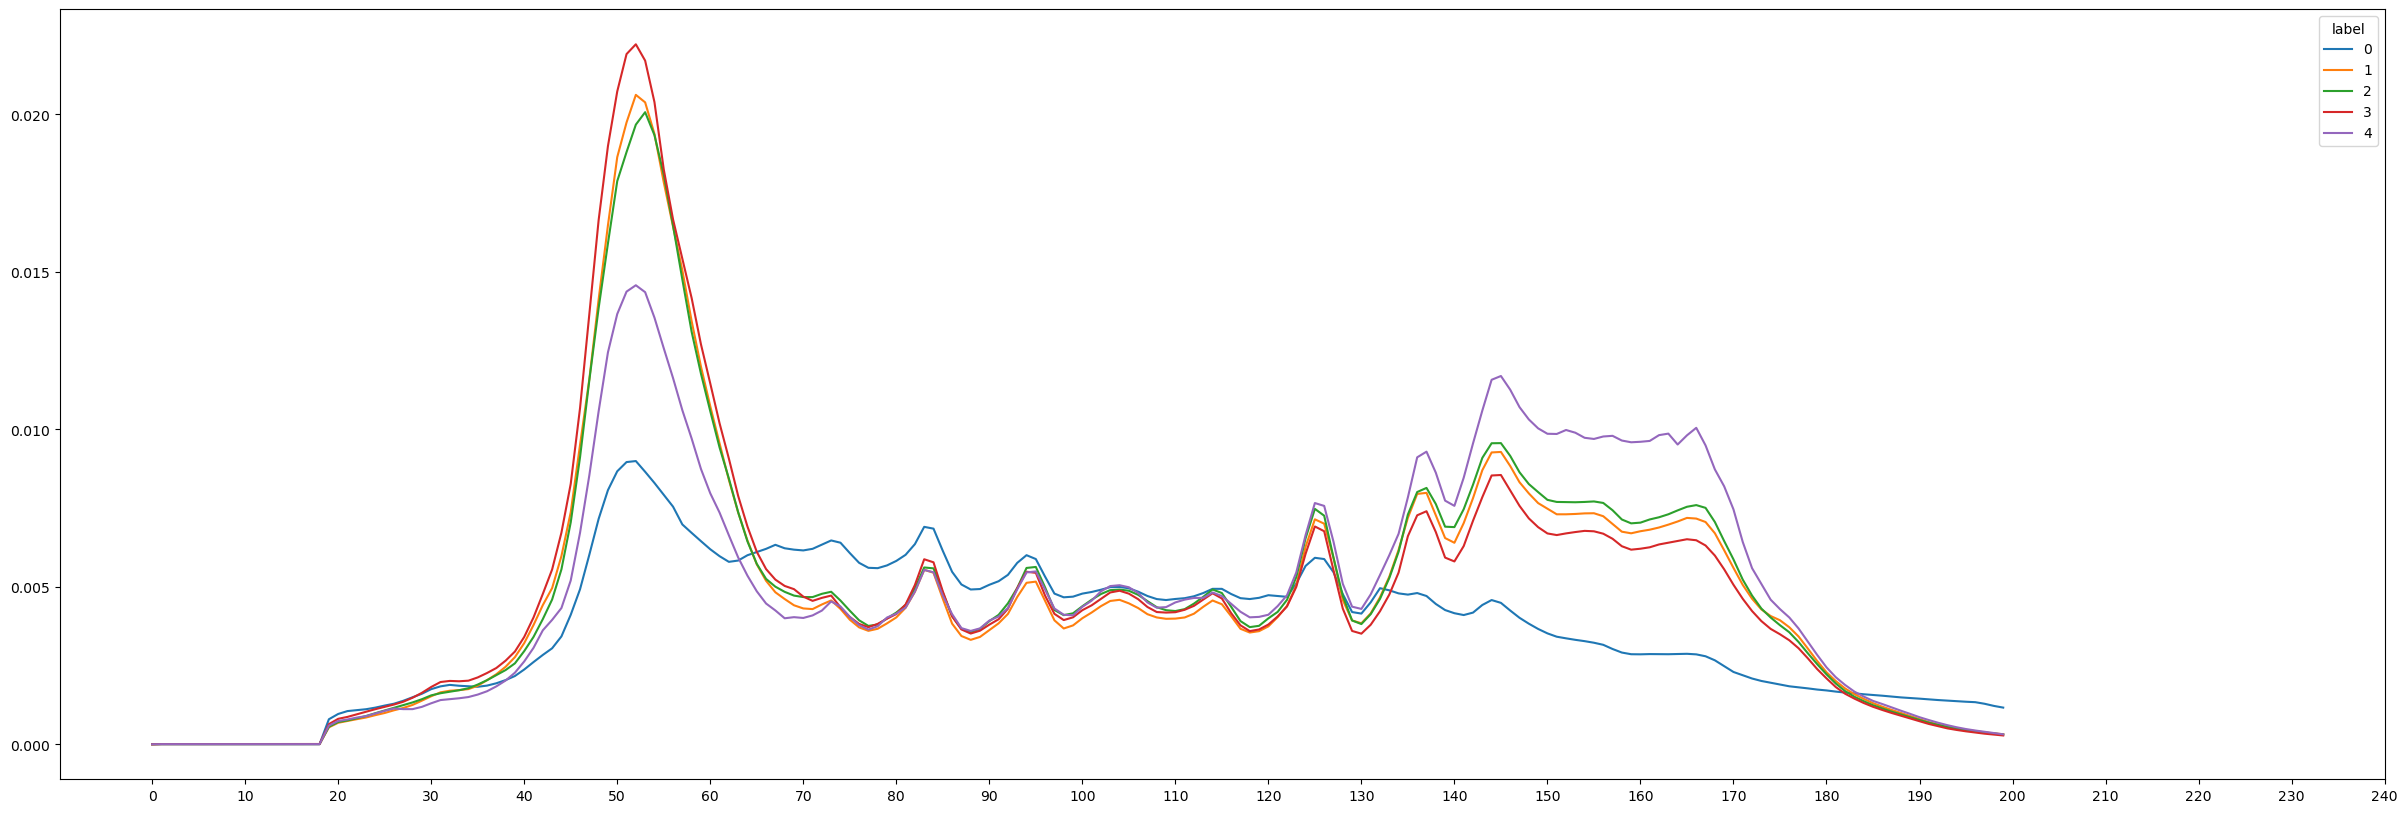

In [8]:
from matplotlib.pyplot import xticks
ax = sdf.fl_dist.fl_df.T.loc[:, :200].join(pd.DataFrame(sdf)[['sample_id', 'label']].set_index("sample_id")).groupby('label').median().T.plot(figsize=(30, 10))
_ = xticks(range(0, 250, 10), map(str, range(0, 250, 10)))

# Region Selection

In [9]:
# find counts for all of the regions
rdf_raw = build_ctcf_binding_sites().label_balanced('cell_type').resize_regions(128)
repeats_rdf = RegionDataFrame.from_bed("/scratch/karius/annotation/mappability.simple_repeats.sorted.bed.gz", ref=rdf_raw.ref)
rdf = rdf_raw.drop_overlapping_regions(repeats_rdf)

In [10]:
from fragmentomics_tools.bias_correction.model import BackgroundModelModule
# model = BackgroundModelModule.load(f'/scratch/karius/bias_correction_model/merged.accessible_regions.negative_binomial.res').cuda()
model = BackgroundModelModule.load(f'/scratch/karius/bias_correction_model/tss_model/merged.off_promoters.multinomial.6.res').cuda()
pred = model.predict_from_rdf(rdf)

build background dists: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1083/1083 [00:01<00:00, 835.17it/s]


In [11]:
pred

,pred_dist.strand_+__fl_40_65__coverage_first,pred_dist.strand_+__fl_40_65__coverage_last,pred_dist.strand_+__fl_40_65__coverage_midpoint,pred_dist.strand_+__fl_120_175__coverage_first,pred_dist.strand_+__fl_120_175__coverage_last,pred_dist.strand_+__fl_120_175__coverage_midpoint,pred_dist.strand_-__fl_40_65__coverage_first,pred_dist.strand_-__fl_40_65__coverage_last,pred_dist.strand_-__fl_40_65__coverage_midpoint,pred_dist.strand_-__fl_120_175__coverage_first,pred_dist.strand_-__fl_120_175__coverage_last,pred_dist.strand_-__fl_120_175__coverage_midpoint
6,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...
12,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...
22,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...
24,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...
29,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...
...,...,...,...,...,...,...,...,...,...,...,...,...
9261,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._mult

In [12]:
rdf = rdf.join(pred)

In [13]:
rdf

,contig,start,stop,strand,cell_type,pred_dist.strand_+__fl_40_65__coverage_first,pred_dist.strand_+__fl_40_65__coverage_last,pred_dist.strand_+__fl_40_65__coverage_midpoint,pred_dist.strand_+__fl_120_175__coverage_first,pred_dist.strand_+__fl_120_175__coverage_last,pred_dist.strand_+__fl_120_175__coverage_midpoint,pred_dist.strand_-__fl_40_65__coverage_first,pred_dist.strand_-__fl_40_65__coverage_last,pred_dist.strand_-__fl_40_65__coverage_midpoint,pred_dist.strand_-__fl_120_175__coverage_first,pred_dist.strand_-__fl_120_175__coverage_last,pred_dist.strand_-__fl_120_175__coverage_midpoint
6,chr1,1344735,1344863,+,colon,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...
12,chr1,2562029,2562157,-,blood,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...
22,chr1,3910651,3910779,-,colon,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...
24,chr1,4826204,4826332,-,neural,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...
29,chr1,6082433,6082561,+,neural,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9261,chrX,155057471,155057599,-,all,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinomial_frozen ...,<scipy.stats._multivariate.multinom

# Sample and Region DataFrame

In [14]:
srdf_raw = SampleAndRegionDataFrame.init_from_rdf_and_sdf(rdf, sdf).attach_fragment_arrays(num_cores=32, min_mapq=10)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 330315/330315 [04:57<00:00, 1109.81it/s]


In [15]:
srdf = srdf_raw.replace(to_replace='fragment_array', value=srdf_raw.fragment_array.progress_apply(lambda fa: fa.drop_duplicate_fragments()))

predict bias: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 330315/330315 [00:41<00:00, 7952.05it/s]


In [16]:
srdf = srdf_raw.filter_outlier_counts(10) 	

predict bias: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 330315/330315 [00:56<00:00, 5860.09it/s]


In [16]:
srdf.df

,contig,start,stop,strand,cell_type,pred_dist.strand_+__fl_40_65__coverage_first,pred_dist.strand_+__fl_40_65__coverage_last,pred_dist.strand_+__fl_40_65__coverage_midpoint,pred_dist.strand_+__fl_120_175__coverage_first,pred_dist.strand_+__fl_120_175__coverage_last,...,pred_dist.strand_-__fl_120_175__coverage_last,pred_dist.strand_-__fl_120_175__coverage_midpoint,sample_id,label,frag_h5,DIAGNOSIS,ENDO_CATEGORY,Cluster,SITE_NUMBER,fragment_array
6,chr1,1344735,1344863,+,colon,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,RD-36067,0,<fragments_h5.fragments_h5.FragmentsH5 object ...,Asymptomatic,Asymptomatic,NaN,Site_7,"RegionFragmentArray(n_frags=41, region=chr1:+:..."
7,chr1,1344735,1344863,+,colon,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,RD-36069,0,<fragments_h5.fragments_h5.FragmentsH5 object ...,Asymptomatic,Asymptomatic,NaN,Site_19,"RegionFragmentArray(n_frags=18, region=chr1:+:..."
9,chr1,1344735,1344863,+,colon,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,RD-36071,0,<fragments_h5.fragments_h5.FragmentsH5 object ...,Asymptomatic,Asymptomatic,NaN,Site_8,"RegionFragmentArray(n_frags=13, region=chr1:+:..."
10,chr1,1344735,1344863,+,colon,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,RD-36072,0,<fragments_h5.fragments_h5.FragmentsH5 object ...,Asymptomatic,Asymptomatic,NaN,Site_19,"RegionFragmentArray(n_frags=41, region=chr1:+:..."
12,chr1,1344735,1344863,+,colon,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,RD-36074,0,<fragments_h5.fragments_h5.FragmentsH5 object ...,Asymptomatic,Asymptomatic,NaN,Site_7,"RegionFragmentArray(n_frags=12, region=chr1:+:..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329694,chrX,152642093,152642221,+,neural,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,RD-56173,4,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Severe,Patient Group 2,Site_13,"RegionFragmentArray(n_frags=37, region=chrX:+:..."
329695,chrX,152642093,152642221,+,neural,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.

In [17]:
dhs_rdf = RegionDataFrame(
    pd.read_csv("/scratch/karius/annotation/DHS_Index_and_Vocabulary_hg38_WM20190703.min2samp.random500k.blacklist_filt.bed", sep="\t"),
    ref='hg38'
).resize_regions(1024)
dhs_rdf['strand'] = '.'
ctcf_rdf = build_ctcf_binding_sites().resize_regions(1024)
intersect_rdf = dhs_rdf.intersect_with_rdf(ctcf_rdf).drop_duplicates()
train_and_val_rdf = dhs_rdf.loc[~dhs_rdf.index.isin(intersect_rdf.index), :].sample(frac=1.0)
train_rdf = train_and_val_rdf.head(500000)
val_rdf = train_and_val_rdf.tail(40000)
train_rdf.shape, val_rdf.shape, ctcf_rdf.shape

WARNING	2024-04-15 14:23:29,783	/tmp/ipykernel_3077/3178245545.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv("/scratch/karius/annotation/DHS_Index_and_Vocabulary_hg38_WM20190703.min2samp.random500k.blacklist_filt.bed", sep="\t"),



((500000, 11), (40000, 11), (9267, 5))

In [18]:
train_rdf

,contig,start,stop,identifier,mean_signal,numsamples,summit,core_start,core_end,component,strand
76993,chr11,10402608,10403632,11.169446,0.641193,6,10403130,10403112.0,10403152.0,Placental / trophoblast,.
257350,chr2,95257967,95258991,2.454041,0.929778,14,95258490,95258470.0,95258490.0,Stromal B,.
385783,chr5,9453719,9454743,5.146875,1.391400,85,9454230,9454150.0,9454290.0,Stromal B,.
326809,chr3,56681733,56682757,3.357316,0.721780,30,56682250,56682170.0,56682326.0,Tissue invariant,.
117033,chr12,86550860,86551884,12.684476,1.098521,39,86551390,86551310.0,86551430.0,Musculoskeletal,.
...,...,...,...,...,...,...,...,...,...,...,...
19647,chr1,87795251,87796275,1.417344,0.623107,3,87795830,87795830.0,87795887.0,Renal / cancer,.
533181,chrX,38165738,38166762,X.320196,0.339460,2,38166320,38166292.0,38166348.0,Neural,.
250454,chr2,52171028,52172052,2.293868,0.490284,10,52171530,52171510.0,52171550.0,Digestive,.
531283,chrX,21374682,21375706,X.2233605,0.279257,59,21375190,21375070.0,21375301.0,Primitive / embryonic,.


In [20]:
def build_counts(record):
    fa = record.fragment_array
    pseudo_count = 1./record.fragment_array.length

    # subset_by_fragment_strand('+')
    fwd_cov = fa.subset_fragment_lengths(20, 60).first_covered_base_counts
    fwd_means = record.fwd_start_counts_dist.mean()
    fwd_cov_pred = fwd_cov.sum()*(fwd_means/fwd_means.sum())

    # .subset_by_fragment_strand('-')
    bkwd_cov = fa.subset_fragment_lengths(20, 60).last_covered_base_counts
    bkwd_means = record.bkwd_stop_counts_dist.mean()
    bkwd_cov_pred = bkwd_cov.sum()*(bkwd_means/bkwd_means.sum())

    fwd_bkwd_ratio = fwd_means.sum()/bkwd_means.sum()
    
    fwd_cov_norm = fwd_cov/(fwd_cov_pred.clip(pseudo_count, None))
    fwd_cov_norm *= fwd_cov.sum()/(fwd_cov_norm.sum()+1e-6)

    bkwd_cov_norm = bkwd_cov/(bkwd_cov_pred.clip(pseudo_count, None))
    bkwd_cov_norm *= bkwd_cov.sum()/(bkwd_cov_norm.sum()+1e-6)

    return pd.Series(dict(fwd_cov=fwd_cov, fwd_cov_pred=fwd_cov_pred, fwd_cov_norm=fwd_cov_norm, bkwd_cov=bkwd_cov, bkwd_cov_pred=bkwd_cov_pred, bkwd_cov_norm=bkwd_cov_norm))

def build_aggregated_coverage(srdf):
    tmp = srdf.df.apply(build_counts, axis=1)
    df = pd.DataFrame(list(tmp.sum())).T
    df.columns = tmp.columns
    return df

In [21]:
def calc_stat(df):
    left_score = (df[25:55].sum().fwd_cov_norm - df[25:55].sum().bkwd_cov_norm)/30
    middle_score = abs(df[55:70].sum().fwd_cov_norm - df[55:70].sum().bkwd_cov_norm)/15
    right_score = (df[70:100].sum().bkwd_cov_norm - df[70:100].sum().fwd_cov_norm)/30
    return left_score/(middle_score+1) + right_score/(middle_score+1)

In [22]:
def calc_score(srdf):
    all_score = calc_stat(build_aggregated_coverage(srdf.query("cell_type == 'all'")))
    colon_score = calc_stat(build_aggregated_coverage(srdf.query("cell_type == 'colon'")))
    return 100*colon_score/all_score

In [23]:
import tqdm
tqdm.tqdm.pandas()
def build_scores_df(srdf):
    res =  []
    for sample_id in tqdm.tqdm(srdf.sample_id.value_counts().index.tolist()):
        res.append(pd.Series(dict(sample_id=sample_id, score=calc_score(srdf.query("sample_id == @sample_id")))))
    return pd.DataFrame(res).set_index("sample_id").join(pd.DataFrame(sdf).set_index("sample_id"))[['score', 'label', 'DIAGNOSIS']].sort_values('score') # .boxplot(by='label')

In [24]:
def _correct_score(x):
    return max(x, 1-x)

def calc_AUCs(scores_df):
    res = {}
    for label in range(0, 5):
        labels = ((pred_df.label == label)).astype(int)
        res[f"{label} vs not {label}"] = _correct_score(roc_auc_score(labels, pred_df.score))

    for label in range(1, 5):
        labels = ((pred_df.label >= label)).astype(int)
        res[f" < {label} vs >= {label}"] = _correct_score(roc_auc_score(labels, pred_df.score))
    
    return res


In [26]:
import numpy

def mk_df_from_record(record):
    df = pd.DataFrame(numpy.vstack(tmp.iloc[0])).T
    df.columns = record.index.tolist()
    return df

# calc_stat(mk_df_from_record(tmp.iloc[1]))

In [27]:
tmp = srdf.df.progress_apply(build_counts, axis=1)

  0%|                                                                                                                                                                                                                                                                                                                                | 1/224341 [00:00<4:21:56, 14.27it/s]


AttributeError: 'Series' object has no attribute 'fwd_start_counts_dist'

In [198]:
counts = tmp.progress_apply(lambda x: calc_stat(mk_df_from_record(x)), axis=1)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 224521/224521 [04:07<00:00, 906.81it/s]


In [189]:
counts.value_counts()

0.0    224521
Name: count, dtype: int64

In [108]:
pred_df = build_scores_df(srdf) # pred_df.dropna().clip(0, 100)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 287/287 [01:23<00:00,  3.45it/s]


In [109]:
# corrected Scores
calc_AUCs(pred_df.query("DIAGNOSIS != 'Crohn\\'s Disease'"))

{'0 vs not 0': 0.7052217855137564,
 '1 vs not 1': 0.5767355590885003,
 '2 vs not 2': 0.5490123911176543,
 '3 vs not 3': 0.526236559139785,
 '4 vs not 4': 0.5549019607843138,
 ' < 1 vs >= 1': 0.7052217855137564,
 ' < 2 vs >= 2': 0.5362487360970678,
 ' < 3 vs >= 3': 0.5045198985778856,
 ' < 4 vs >= 4': 0.5549019607843138}

In [103]:
# Uncorrected Scores
calc_AUCs(pred_df.query("DIAGNOSIS != 'Crohn\\'s Disease'"))

{'0 vs not 0': 0.5379000561482313,
 '1 vs not 1': 0.5462639109697933,
 '2 vs not 2': 0.58790332474543,
 '3 vs not 3': 0.5023655913978494,
 '4 vs not 4': 0.5480392156862745,
 ' < 1 vs >= 1': 0.5379000561482313,
 ' < 2 vs >= 2': 0.5509605662285135,
 ' < 3 vs >= 3': 0.5234263036048947,
 ' < 4 vs >= 4': 0.5480392156862745}

In [72]:
labels = ((pred_df.label > 2) & (pred_df.DIAGNOSIS == 'Crohn\'s Disease')).astype(int)
roc_auc_score(labels, pred_df.score)

0.5692972972972973

In [60]:
pred_df

,score,label,DIAGNOSIS
sample_id,,,
RD-50582,-1164.117284,2,Crohn's Disease
RD-56905,-879.907858,1,Ulcerative Colitis
RD-56687,-472.129046,4,Ulcerative Colitis
RD-56426,-332.518906,3,Ulcerative Colitis
RD-36073,-326.774730,0,Asymptomatic
...,...,...,...
RD-36062,224.211547,0,Asymptomatic
RD-36067,227.238247,0,Asymptomatic
RD-57044,239.032442,2,Crohn's Disease


0.4540289256198347

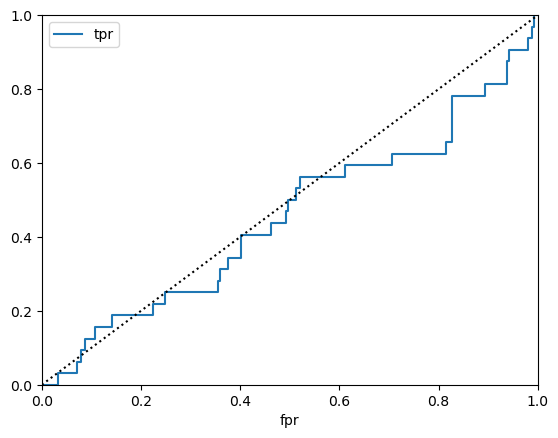

In [80]:
from sklearn import metrics
tmp = pred_df.query("label in (1, 2, 3, 4)")
labels = (tmp.label > 3).astype(int)
fpr, tpr, _ = metrics.roc_curve(labels.ravel(),  tmp.score.values.ravel())
ax = pd.DataFrame(dict(fpr=fpr, tpr=tpr)).plot.line(x='fpr', y='tpr', xlim=(0,1), ylim=(0,1))
ax.axline((0, 0), slope=1, color='black', linestyle='dotted')
roc_auc_score(labels, tmp.score)

In [44]:
from sklearn.metrics import roc_auc_score

In [351]:
labels = (pred_df.label > 1).astype(int)
roc_auc_score(labels, pred_df.score)

0.6280952380952382

In [352]:
labels = (pred_df.label > 2).astype(int)
roc_auc_score(labels, pred_df.score)

0.5714749837556855

In [353]:
labels = (pred_df.label > 3).astype(int)
roc_auc_score(labels, pred_df.score)

0.5738770685579196

In [354]:
tmp = pred_df.query("label in (1, 4)")
labels = (tmp.label > 3).astype(int)
roc_auc_score(labels, tmp.score)

0.638888888888889

In [355]:
tmp = pred_df.query("label in (2, 4)")
labels = (tmp.label > 3).astype(int)
roc_auc_score(labels, tmp.score)

0.5234375

In [356]:
tmp = pred_df.query("label in (3, 4)")
labels = (tmp.label > 3).astype(int)
roc_auc_score(labels, tmp.score)

0.5290404040404041

In [357]:
tmp = pred_df.query("label in (1, 2)")
labels = (tmp.label > 1).astype(int)
roc_auc_score(labels, tmp.score)

0.6322916666666667

In [358]:
tmp = pred_df.query("label in (1, 3)")
labels = (tmp.label > 1).astype(int)
roc_auc_score(labels, tmp.score)

0.6141414141414142

In [359]:
tmp = pred_df.query("label in (2, 3)")
labels = (tmp.label > 2).astype(int)
roc_auc_score(labels, tmp.score)

0.49179292929292934

In [183]:
srdf.df[['sample_id', 'label']].value_counts().index

MultiIndex([('RD-56805', 4),
            ('RD-56417', 1),
            ('RD-56937', 4),
            ('RD-56892', 2),
            ('RD-57090', 4),
            ('RD-56403', 3),
            ('RD-56894', 2),
            ('RD-56406', 3),
            ('RD-56914', 4),
            ('RD-56400', 2),
            ...
            ('RD-56895', 2),
            ('RD-56928', 1),
            ('RD-56416', 1),
            ('RD-56905', 1),
            ('RD-56926', 1),
            ('RD-56685', 4),
            ('RD-56931', 1),
            ('RD-56428', 3),
            ('RD-56676', 1),
            ('RD-56908', 1)],
           names=['sample_id', 'label'], length=165)

In [177]:
scores = make_scores(srdf)
scores

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9617/9617 [00:06<00:00, 1552.75it/s]


ibd          4.350532
remission   -3.491014
dtype: float64

In [174]:
scores

ibd          6.602401
remission   -0.701705
dtype: float64

(<Figure size 2500x800 with 4 Axes>,
 [<Axes: title={'center': 'Cell Type: all -- label == 1'}>,
  <Axes: title={'center': 'Cell Type: all -- label >= 3'}>,
  <Axes: title={'center': 'Cell Type: colon -- label == 1'}>,
  <Axes: title={'center': 'Cell Type: colon -- label >= 3'}, xlabel='NA'>])

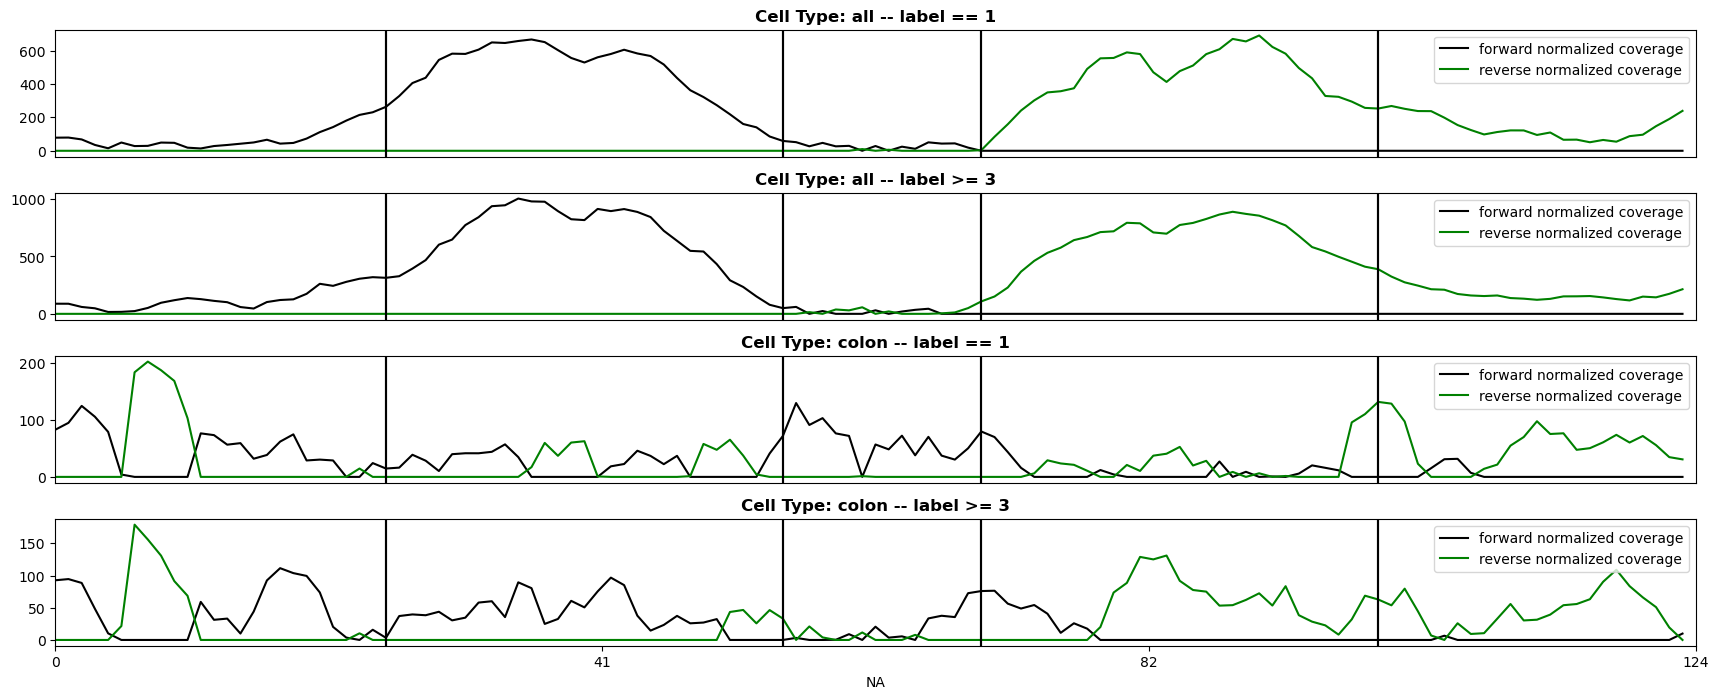

In [128]:
tracks.plot(sharey=False)

(<Figure size 2500x800 with 4 Axes>,
 [<Axes: title={'center': 'Cell Type: all -- label == 1'}>,
  <Axes: title={'center': 'Cell Type: all -- label >= 3'}>,
  <Axes: title={'center': 'Cell Type: colon -- label == 1'}>,
  <Axes: title={'center': 'Cell Type: colon -- label >= 3'}, xlabel='NA'>])

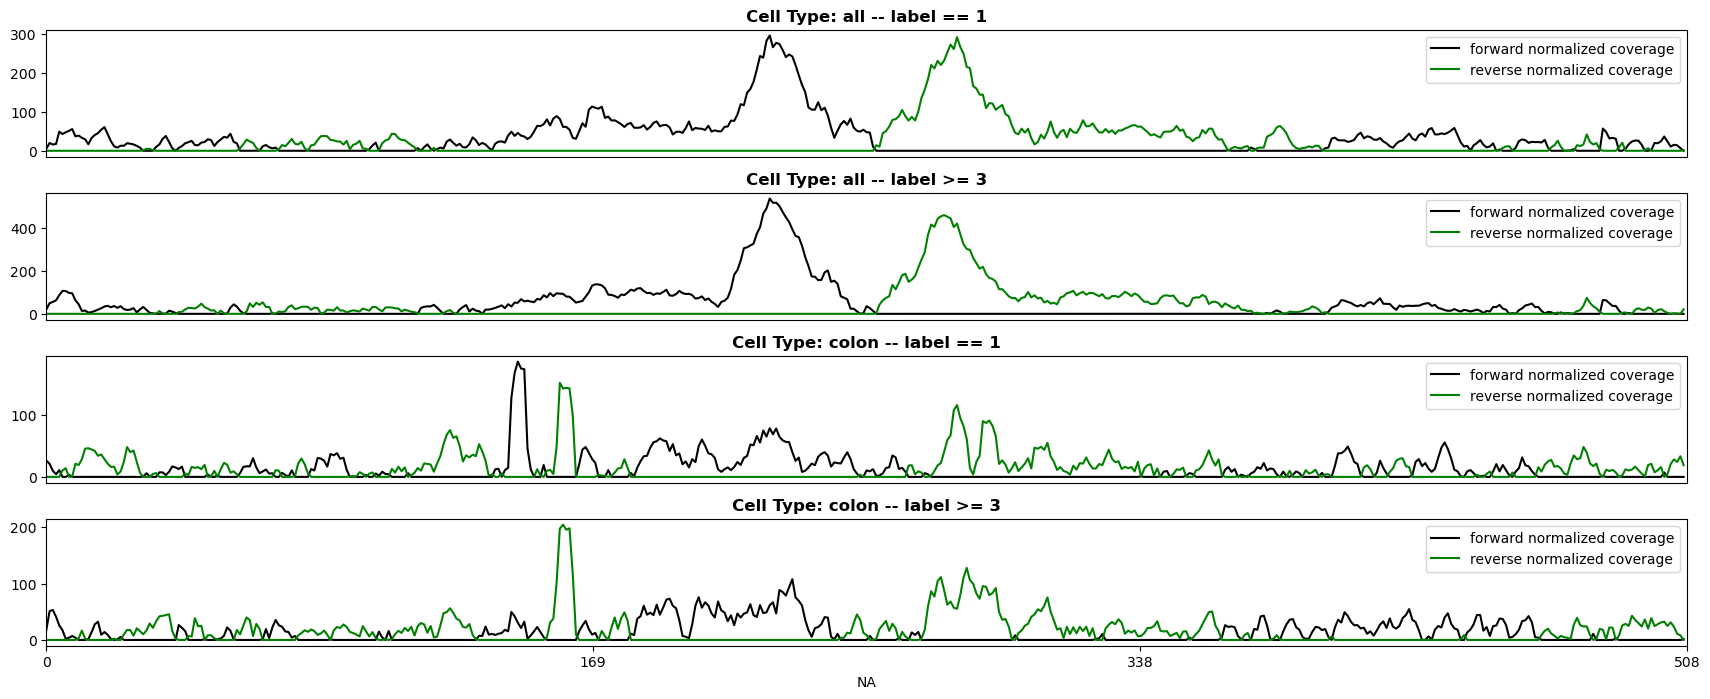

In [83]:
tracks.plot()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2766/2766 [00:02<00:00, 1307.74it/s]


(<Figure size 2500x200 with 1 Axes>, [<Axes: xlabel='NA'>])

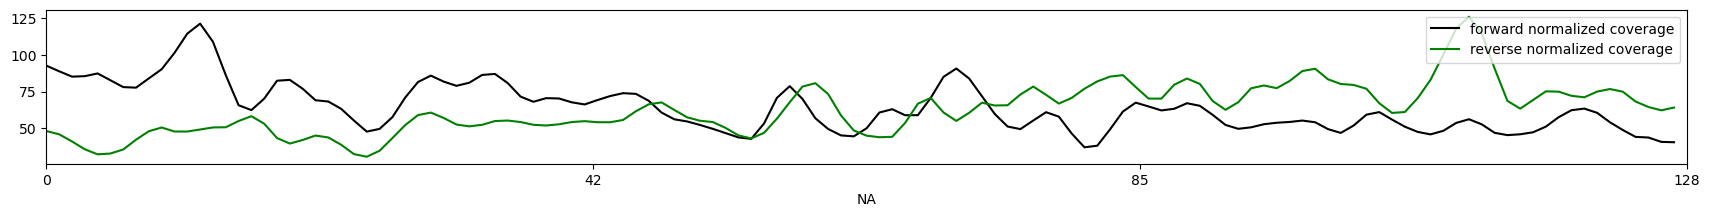

In [51]:
df = build_aggregated_coverage(srdf.query("cell_type == 'neural' and label == 1"))
(VectorTrack(df.fwd_cov_norm, color='black', smooth=True, smooth_window_len=5, name='forward normalized coverage') + VectorTrack(df.bkwd_cov_norm, color='green', smooth=True, smooth_window_len=5, name='reverse normalized coverage')).plot()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2469/2469 [00:01<00:00, 1342.98it/s]


(<Figure size 2500x200 with 1 Axes>, [<Axes: xlabel='NA'>])

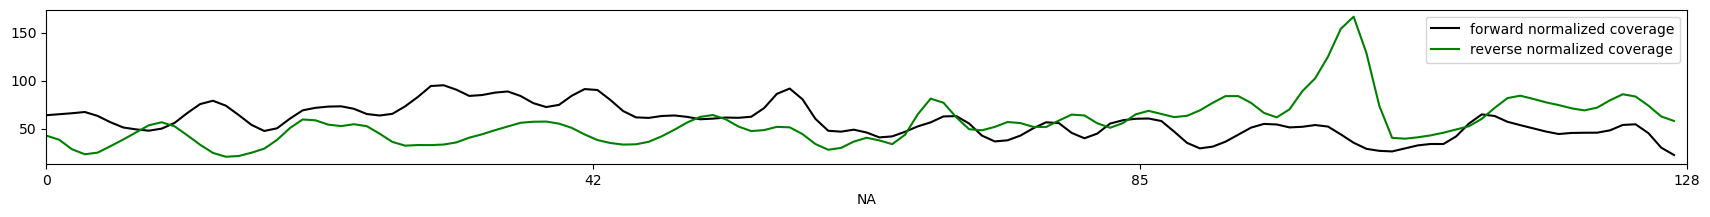

In [41]:
df = build_aggregated_coverage(srdf.query("cell_type == 'colon' and label == 1"))
(VectorTrack(df.fwd_cov_norm, color='black', smooth=True, smooth_window_len=5, name='forward normalized coverage') + VectorTrack(df.bkwd_cov_norm, color='green', smooth=True, smooth_window_len=5, name='reverse normalized coverage')).plot()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3149/3149 [00:02<00:00, 1281.66it/s]


(<Figure size 2500x200 with 1 Axes>, [<Axes: xlabel='NA'>])

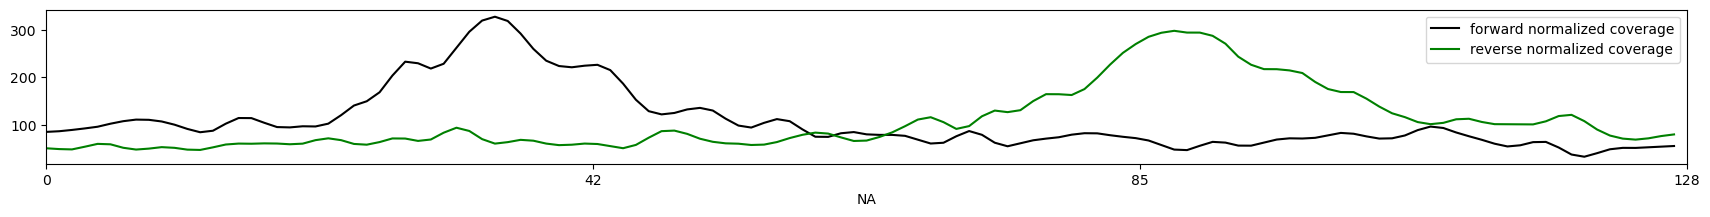

In [45]:
df = build_aggregated_coverage(srdf.query("cell_type == 'all' and label == 1"))
(VectorTrack(df.fwd_cov_norm, color='black', smooth=True, smooth_window_len=5, name='forward normalized coverage') + VectorTrack(df.bkwd_cov_norm, color='green', smooth=True, smooth_window_len=5, name='reverse normalized coverage')).plot()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4266/4266 [00:05<00:00, 813.64it/s]


(<Figure size 2500x200 with 1 Axes>, [<Axes: xlabel='NA'>])

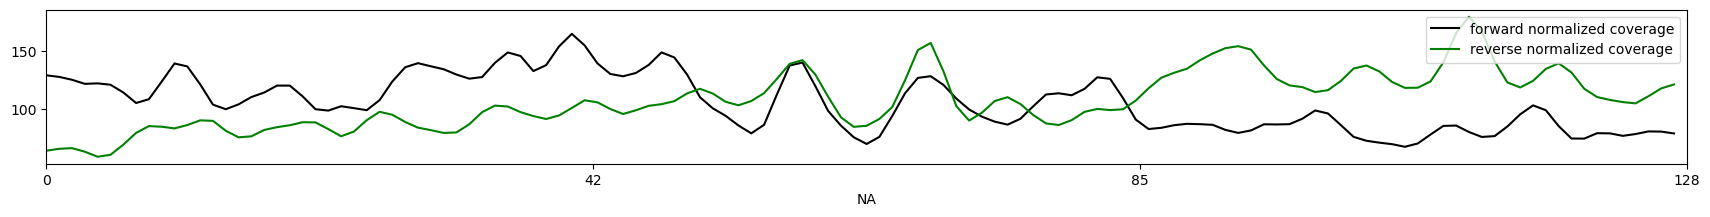

In [52]:
df = build_aggregated_coverage(srdf.query("cell_type == 'neural' and label >= 3"))
(VectorTrack(df.fwd_cov_norm, color='black', smooth=True, smooth_window_len=5, name='forward normalized coverage') + VectorTrack(df.bkwd_cov_norm, color='green', smooth=True, smooth_window_len=5, name='reverse normalized coverage')).plot()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3794/3794 [00:02<00:00, 1315.08it/s]


(<Figure size 2500x200 with 1 Axes>, [<Axes: xlabel='NA'>])

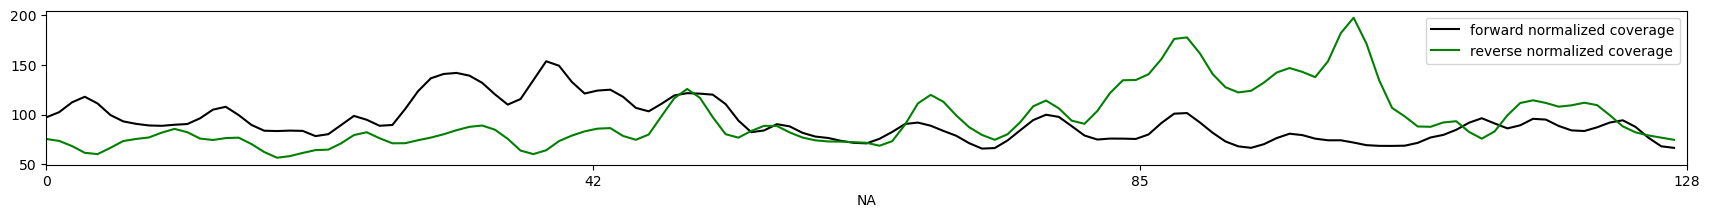

In [42]:
df = build_aggregated_coverage(srdf.query("cell_type == 'colon' and label >= 3"))
(VectorTrack(df.fwd_cov_norm, color='black', smooth=True, smooth_window_len=5, name='forward normalized coverage') + VectorTrack(df.bkwd_cov_norm, color='green', smooth=True, smooth_window_len=5, name='reverse normalized coverage')).plot()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4649/4649 [00:03<00:00, 1282.80it/s]


(<Figure size 2500x200 with 1 Axes>, [<Axes: xlabel='NA'>])

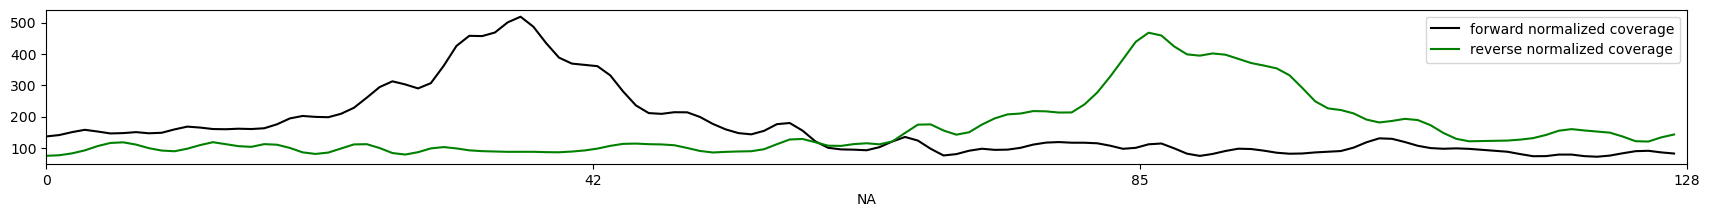

In [47]:
df = build_aggregated_coverage(srdf.query("cell_type == 'all' and label >= 3"))
(VectorTrack(df.fwd_cov_norm, color='black', smooth=True, smooth_window_len=5, name='forward normalized coverage') + VectorTrack(df.bkwd_cov_norm, color='green', smooth=True, smooth_window_len=5, name='reverse normalized coverage')).plot()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3794/3794 [00:02<00:00, 1298.39it/s]


<Axes: >

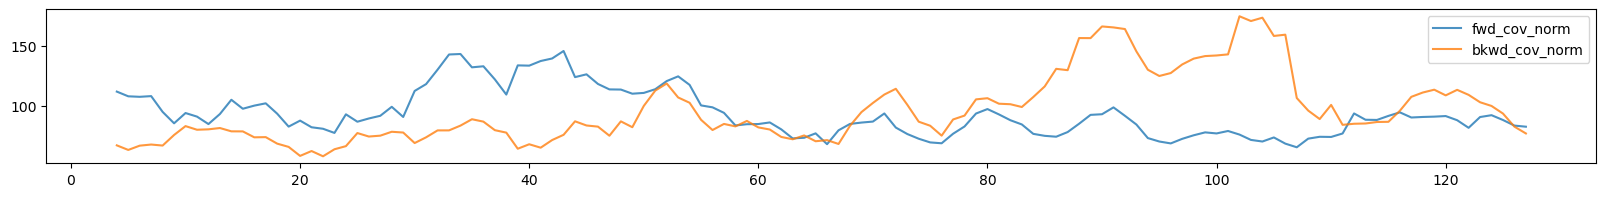

In [20]:
df = build_aggregated_coverage(srdf.query("cell_type == 'colon' and label >= 3"))
tmp = df.rolling(5).mean().dropna()
tmp.loc[:, ('fwd_cov_norm', 'bkwd_cov_norm')].plot(figsize=(20, 2), alpha=0.8)

<Axes: >

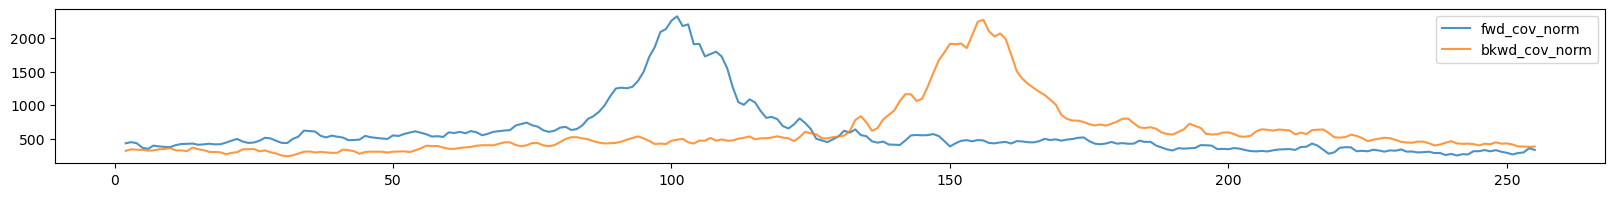

<Axes: >

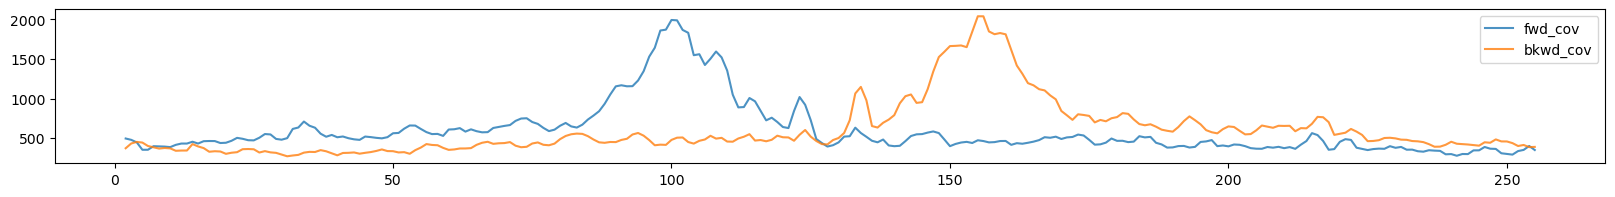

In [602]:
withtmp.loc[:, ('fwd_cov', 'bkwd_cov')].plot(figsize=(20, 2), alpha=0.8)

# Plotting

In [18]:
patient_groups = ['Patient Group  1', 'Patient Group  2']
patient_groups = sdf.Cluster.unique().tolist()

severities = ('Remission', 'Mild', 'Moderate', 'Severe')

from fragmentomics_tools.plot.tracks import CoverageTrack, VLine, Tracks, VplotTrack, StrandSplitCoverageTrack, VectorTrack

from fragmentomics_tools.plot.tracks import Tracks, VectorTrack, VLine

def SmoothedCoverageTrack(srdf, name='', sm_win=5):
    df = build_aggregated_coverage(srdf).rolling(sm_win).mean().dropna() 
    min_cov = df[['fwd_cov_norm', 'bkwd_cov_norm']].min(axis=1)
    fwd_track = VectorTrack(df.fwd_cov_norm-min_cov, color='black', name='forward normalized coverage')
    rev_track = VectorTrack(df.bkwd_cov_norm-min_cov, color='green', name='reverse normalized coverage')
    combined = fwd_track + rev_track
    combined.name = name
    return combined


def make_all_tracks(srdf):
    tracks = Tracks()
    cell_types = srdf.cell_type.value_counts().index.tolist()
    
    for cell_type in ['all', 'colon']:
        for label_query in ("label == 1", "label >= 3"):
            tracks.append(SmoothedCoverageTrack(srdf.query(f"cell_type == @cell_type and {label_query}"), name=f"Cell Type: {cell_type} -- {label_query}"))
            tracks[-1].vlines = [VLine(25), VLine(55), VLine(70), VLine(100)]
    return tracks

def make_tracks(fa, extra_tracks=False, include_cutsites=False, include_vplot=False):
    region_size = fa.shape[1]

    smooth_window = 1
    region_size//2+145
    first_nuc=132
    offset=175
    tracks = Tracks()
    if include_vplot:
        tracks.append(VplotTrack(fa, fa.plot_region, sum_pool_by=2))

    for strand in ['+', '-']:
        sub_fa = fa.subset_by_fragment_strand(strand)
        for frag_lens in ((40, 60), (80, 500)):
            tracks.append(
                CoverageTrack(sub_fa, fa.plot_region, coverage_type='left_endpoint', n_boot_coverage=0, fraction=frag_lens, smooth_window=smooth_window, 
                              vlines=[VLine(x=region_size//2)], 
                              name=f'fraglens: {frag_lens} strand: {strand} left endpoint') 
                + CoverageTrack(sub_fa, fa.plot_region, coverage_type='right_endpoint', n_boot_coverage=0, fraction=frag_lens, smooth_window=smooth_window, 
                                vlines=[VLine(x=region_size//2)], 
                                name=f' - right endpoint'))
    tracks.append(StrandSplitCoverageTrack(fa, fa.plot_region, coverage_type='midpoint', n_boot_coverage=10, fraction=(20, 40), smooth_window=10, ylim=(0, None),
                                vlines=[VLine(x=region_size//2)], 
                                name='Very Small Peak (20 - 40)'))
    tracks.append(StrandSplitCoverageTrack(fa, fa.plot_region, coverage_type='midpoint', n_boot_coverage=10, fraction=(40, 60), smooth_window=10, ylim=(0, None),
                                vlines=[VLine(x=region_size//2)], 
                                name='50 BP Peak (40 - 60)'))
    
    """
    if extra_tracks:
        tracks.append(StrandSplitCoverageTrack(fa, fa.plot_region, coverage_type='left_endpoint', n_boot_coverage=0, fraction=(20, 40), smooth_window=200, ylim=(0, None),
                                vlines=[VLine(x=region_size//2)], 
                                name='Very Small Peak (20 - 40)'))
        tracks.append(StrandSplitCoverageTrack(fa, fa.plot_region, coverage_type='left_endpoint', n_boot_coverage=0, fraction=(40, 60), smooth_window=200, ylim=(0, None),
                                vlines=[VLine(x=region_size//2)], 
                                name='50 BP Peak (40 - 60)'))
    tracks.append(StrandSplitCoverageTrack(fa, fa.plot_region, coverage_type='left_endpoint', n_boot_coverage=0, fraction=(60, 100), smooth_window=200, ylim=(0, None),
                                vlines=[VLine(x=region_size//2)], 
                                name='sub-nucleosome (60 - 100)'))
    tracks.append(StrandSplitCoverageTrack(fa, fa.plot_region, coverage_type='left_endpoint', n_boot_coverage=0, fraction=(110, 500), smooth_window=500, ylim=(0, None),
                                #vlines=[VLine(x=region_size//2+first_nuc+x*offset) for x in range(8)] + [VLine(x=region_size//2-first_nuc-x*offset) for x in range(8)], 
                                name='nucleosome (> 110)'))
    """
    return tracks

# Analysis

In [241]:
srdf.query("label == 4").cell_type.value_counts()

cell_type
neural    5892
colon     5272
blood     5115
all       4975
Name: count, dtype: int64

In [242]:
import tqdm
tqdm.tqdm._instances.clear()
tmp = srdf.resize_regions(256)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 194799/194799 [00:56<00:00, 3421.88it/s]


(<Figure size 2500x3200 with 18 Axes>,
 [<Axes: title={'center': ' 156963 frags'}>,
  <Axes: title={'center': ' 121125 frags'}>,
  <Axes: title={'center': 'fraglens: (40, 60) strand: + left endpoint  - right endpoint'}>,
  <Axes: title={'center': 'fraglens: (40, 60) strand: + left endpoint  - right endpoint'}>,
  <Axes: title={'center': 'fraglens: (80, 500) strand: + left endpoint  - right endpoint'}>,
  <Axes: title={'center': 'fraglens: (80, 500) strand: + left endpoint  - right endpoint'}>,
  <Axes: title={'center': 'fraglens: (40, 60) strand: - left endpoint  - right endpoint'}>,
  <Axes: title={'center': 'fraglens: (40, 60) strand: - left endpoint  - right endpoint'}>,
  <Axes: title={'center': 'fraglens: (80, 500) strand: - left endpoint  - right endpoint'}>,
  <Axes: title={'center': 'fraglens: (80, 500) strand: - left endpoint  - right endpoint'}>,
  <Axes: title={'center': 'Very Small Peak (20 - 40) - Fwd Strand Very Small Peak (20 - 40) - Rev Strand'}>,
  <Axes: title={'cente

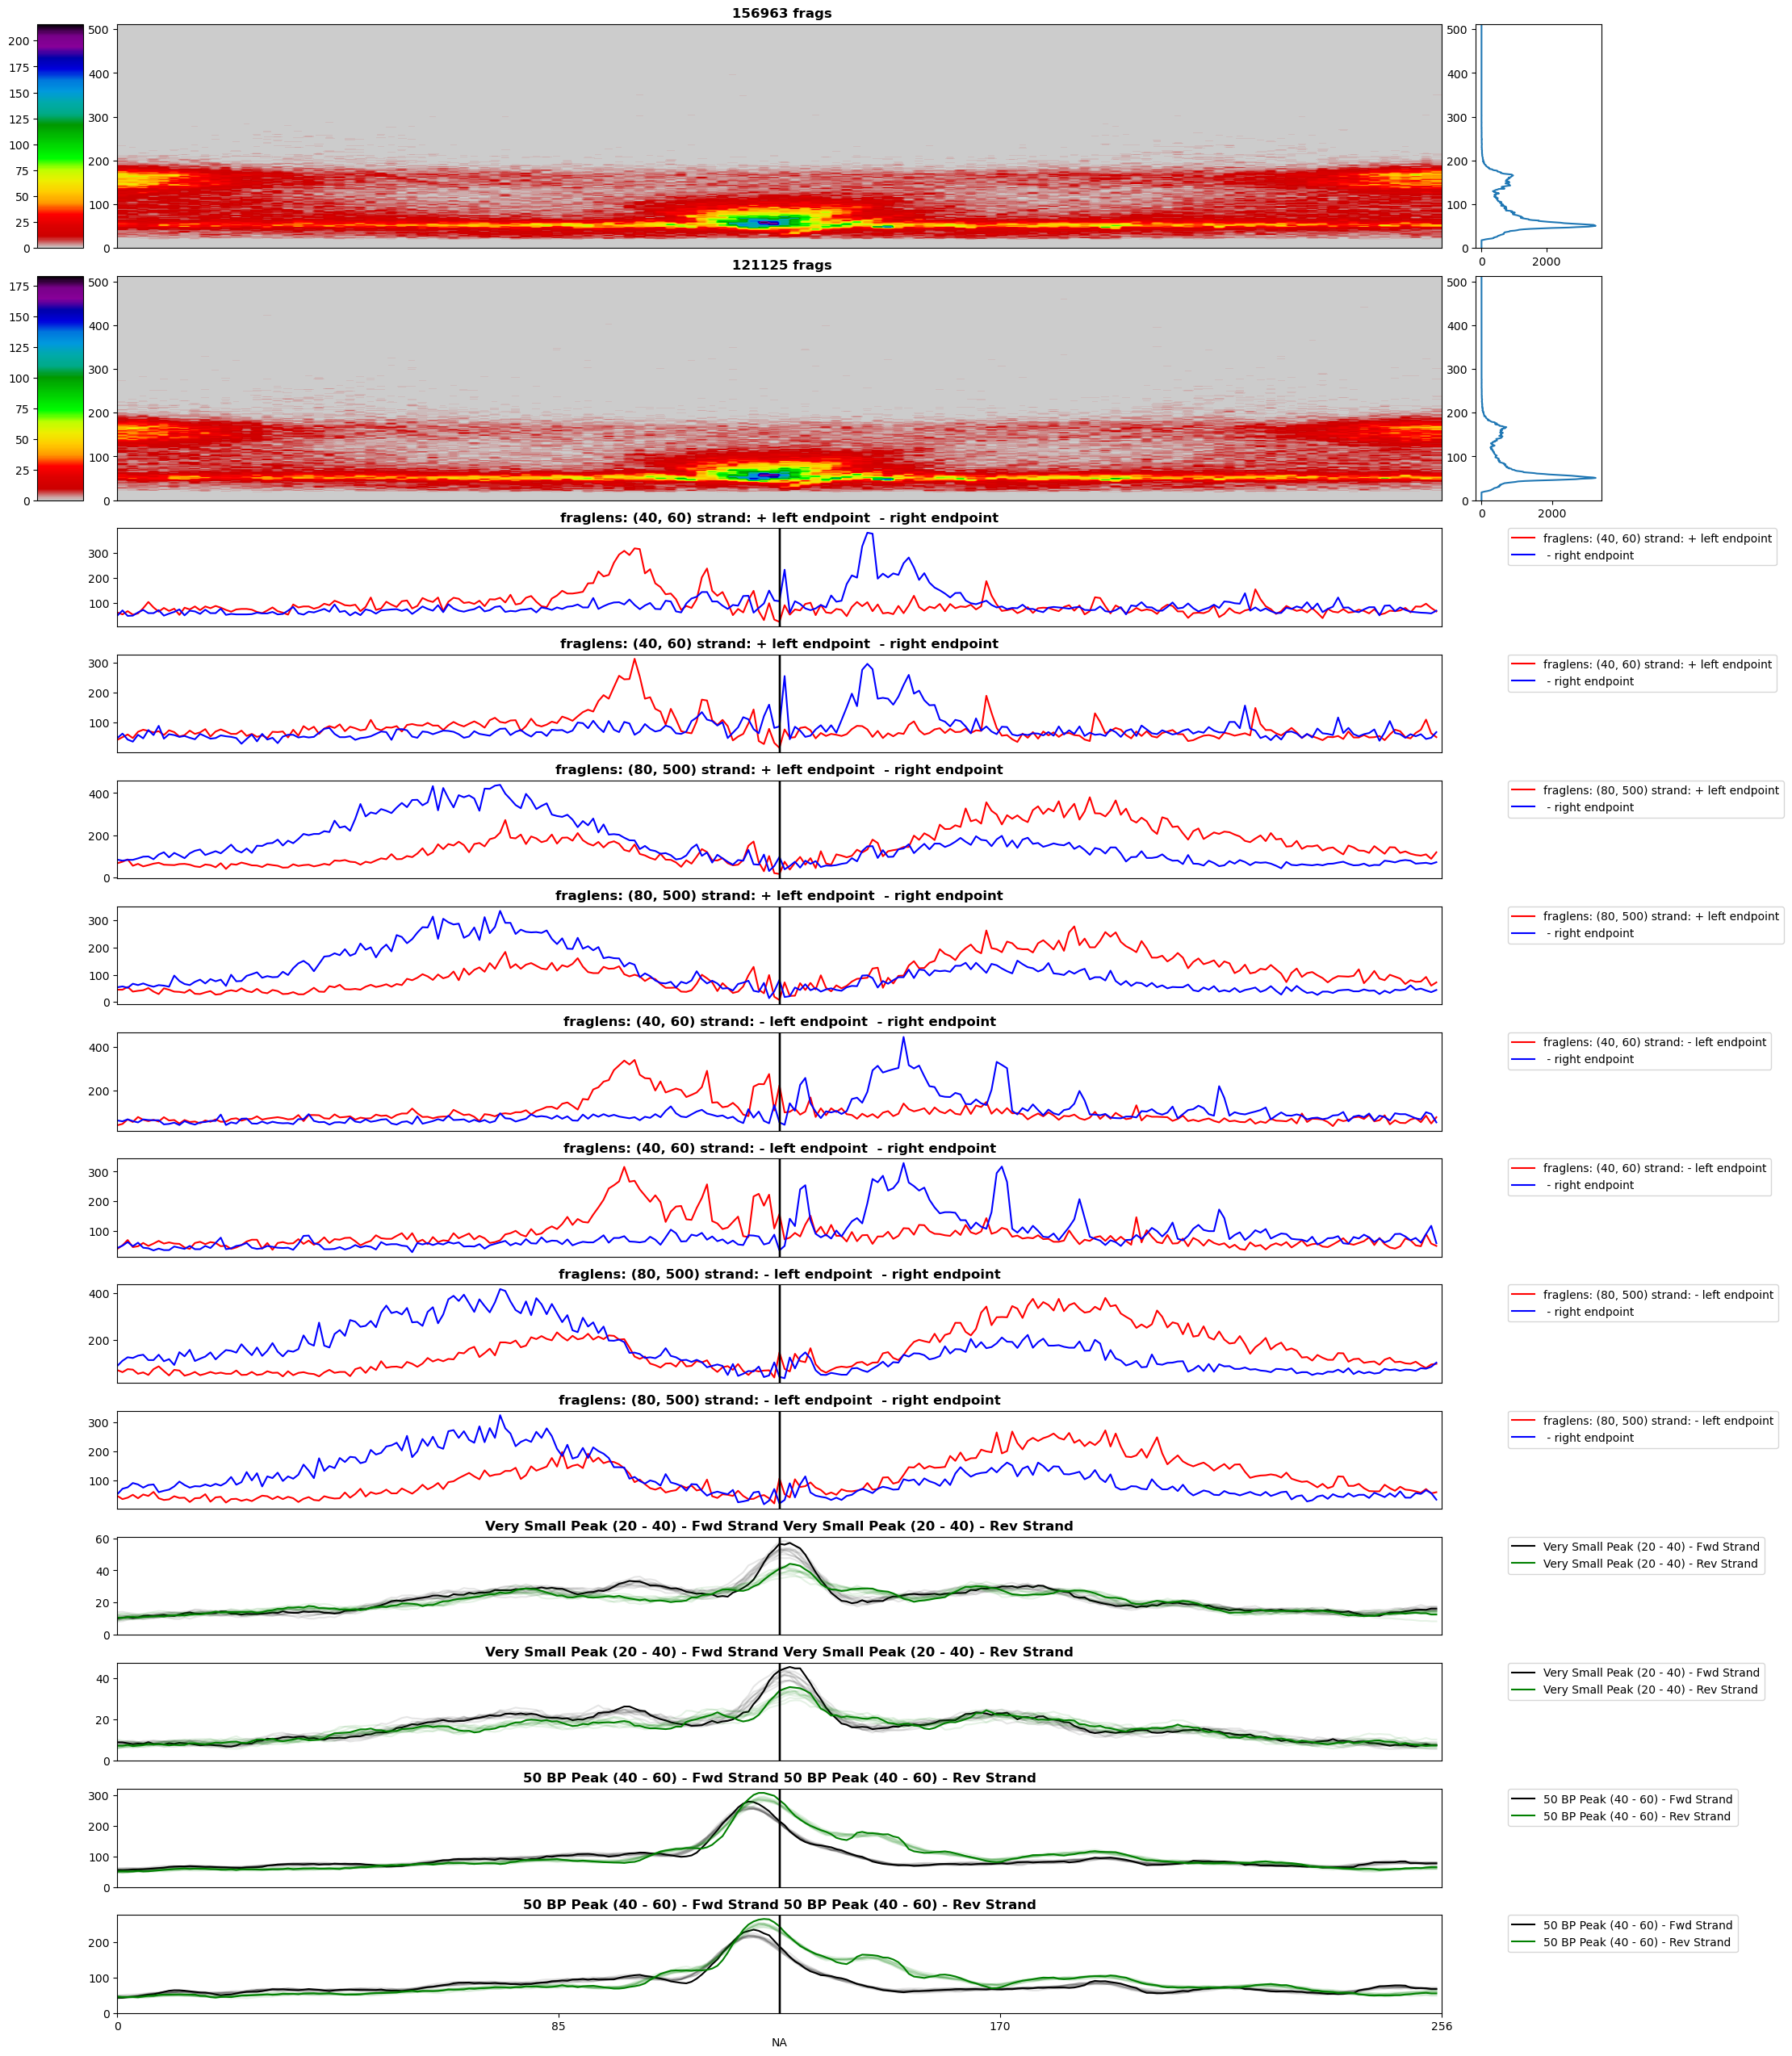

In [243]:
all_fa = merge_fragment_arrays([x.drop_duplicate_fragments() for x in tmp.query("cell_type == 'all' and label >= 3").fragment_array.tolist()])
label_4_tracks = make_tracks(all_fa, True, True, True)
all_fa = merge_fragment_arrays([x.drop_duplicate_fragments() for x in tmp.query("cell_type == 'all' and label == 1").fragment_array.tolist()])
label_1_tracks = make_tracks(all_fa, True, True, True)
Tracks(itertools.chain(*zip(label_4_tracks, label_1_tracks))).plot()

(<Figure size 2500x3200 with 18 Axes>,
 [<Axes: title={'center': ' 163251 frags'}>,
  <Axes: title={'center': ' 123704 frags'}>,
  <Axes: title={'center': 'fraglens: (40, 60) strand: + left endpoint  - right endpoint'}>,
  <Axes: title={'center': 'fraglens: (40, 60) strand: + left endpoint  - right endpoint'}>,
  <Axes: title={'center': 'fraglens: (80, 500) strand: + left endpoint  - right endpoint'}>,
  <Axes: title={'center': 'fraglens: (80, 500) strand: + left endpoint  - right endpoint'}>,
  <Axes: title={'center': 'fraglens: (40, 60) strand: - left endpoint  - right endpoint'}>,
  <Axes: title={'center': 'fraglens: (40, 60) strand: - left endpoint  - right endpoint'}>,
  <Axes: title={'center': 'fraglens: (80, 500) strand: - left endpoint  - right endpoint'}>,
  <Axes: title={'center': 'fraglens: (80, 500) strand: - left endpoint  - right endpoint'}>,
  <Axes: title={'center': 'Very Small Peak (20 - 40) - Fwd Strand Very Small Peak (20 - 40) - Rev Strand'}>,
  <Axes: title={'cente

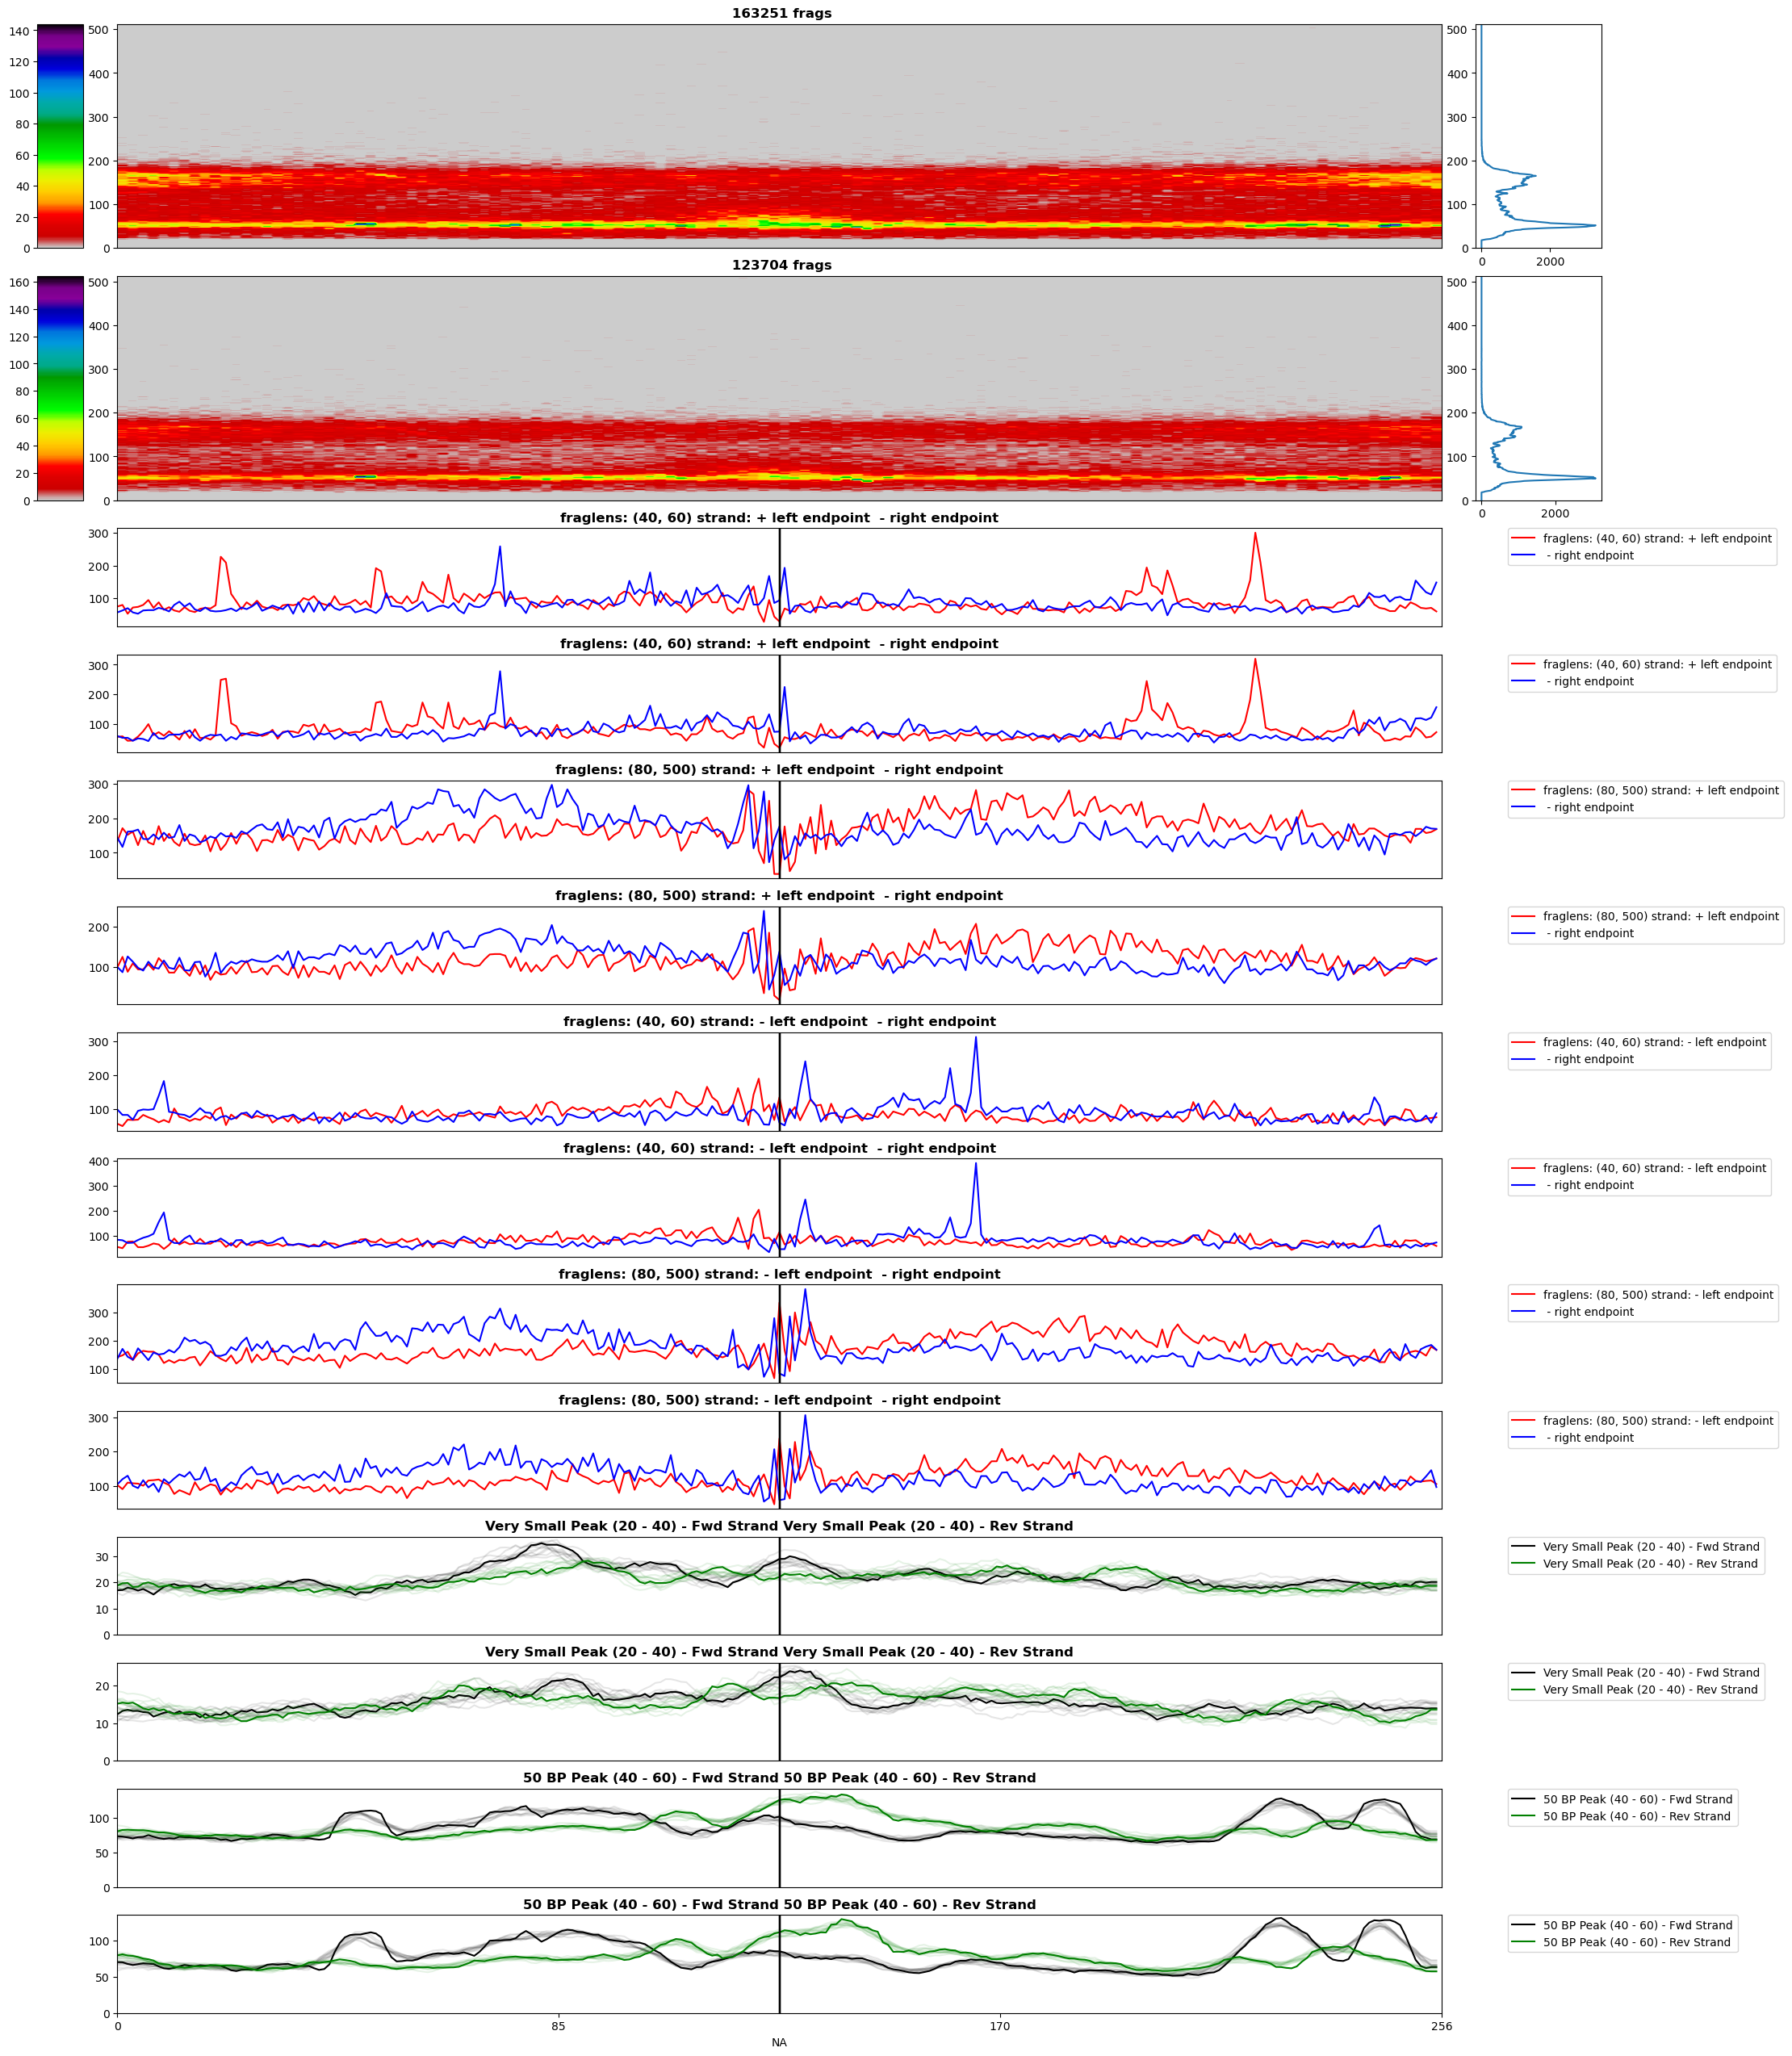

In [244]:
all_fa = merge_fragment_arrays([x.drop_duplicate_fragments() for x in tmp.query("cell_type == 'colon' and label >= 3").fragment_array.tolist()])
label_4_tracks = make_tracks(all_fa, True, True, True)
all_fa = merge_fragment_arrays([x.drop_duplicate_fragments() for x in tmp.query("cell_type == 'colon' and label == 1").fragment_array.tolist()])
label_1_tracks = make_tracks(all_fa, True, True, True)
Tracks(itertools.chain(*zip(label_4_tracks, label_1_tracks))).plot()

# FL Normalize

WARNING	2024-02-08 05:23:50,544	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:23:51,031	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:23:51,507	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:23:52,032	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:23:52,669	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:23:53,233	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:23:53,836	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:23:54,322	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:23:54,855	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:23:55,406	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:23:55,870	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:23:56,379	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-

WARNING	2024-02-08 05:24:23,764	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:24:24,214	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:24:24,663	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:24:25,127	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:24:25,581	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:24:26,048	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:24:26,533	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:24:27,171	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:24:27,648	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:24:28,111	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:24:28,572	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:24:29,047	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-

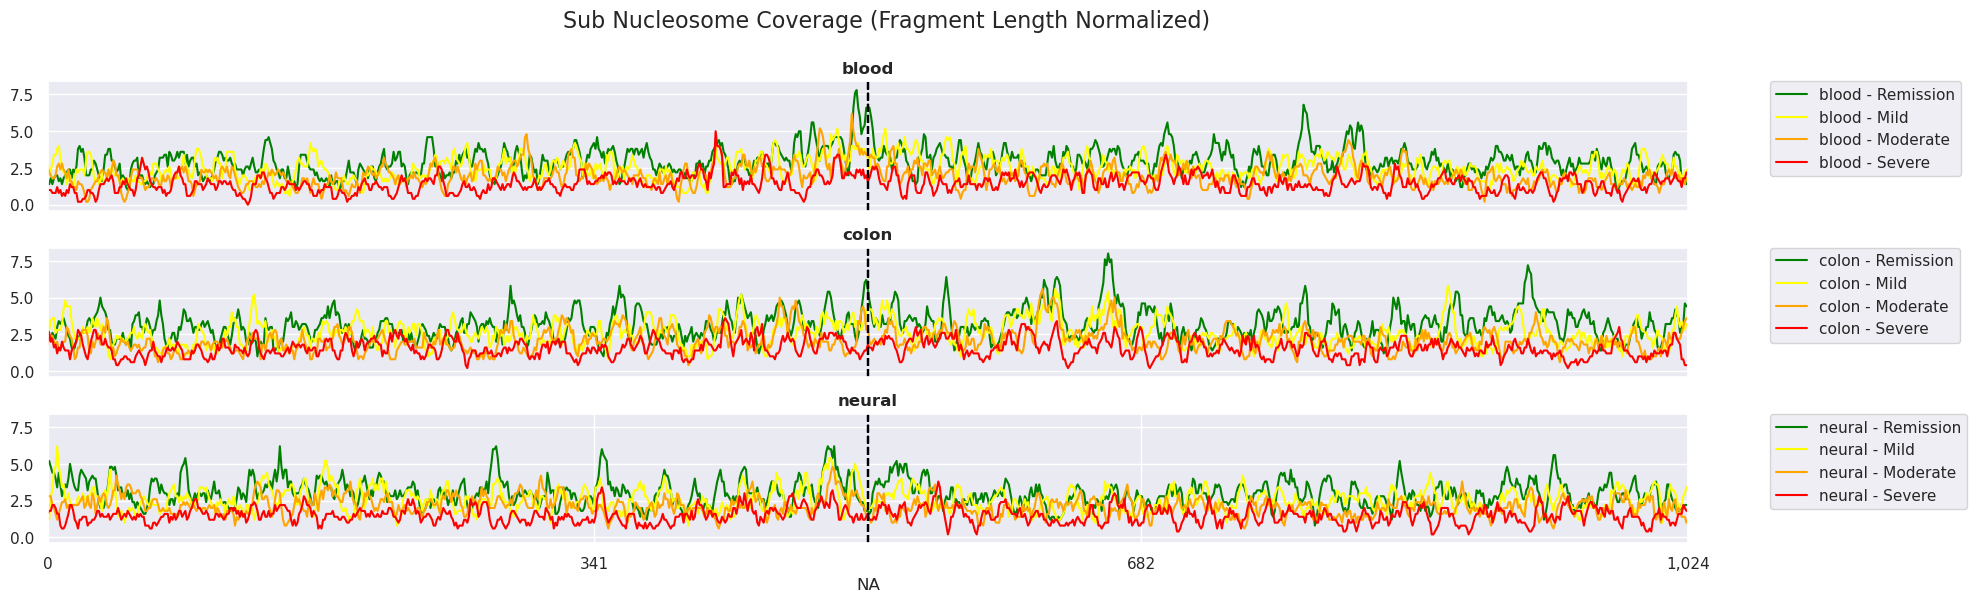

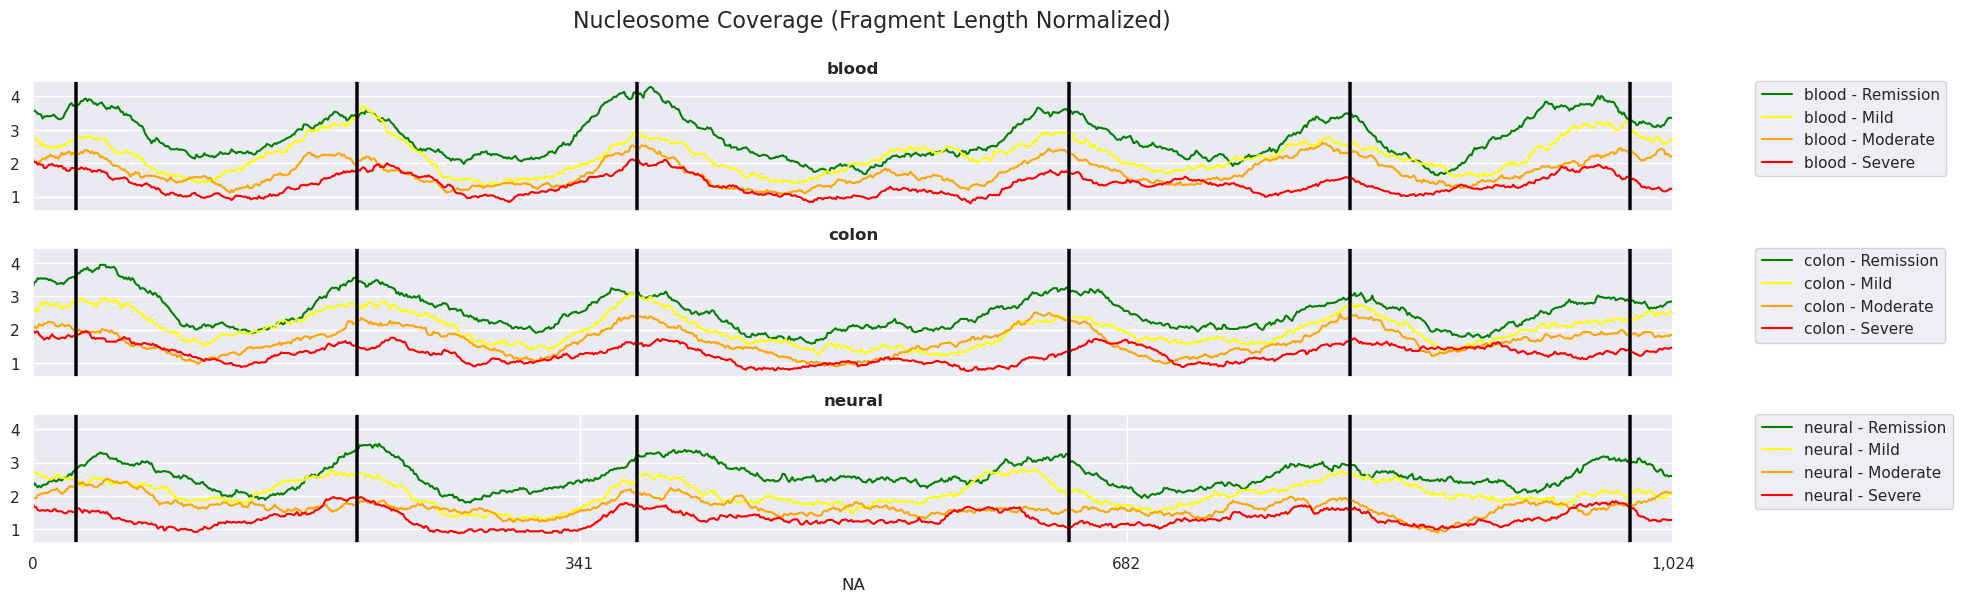

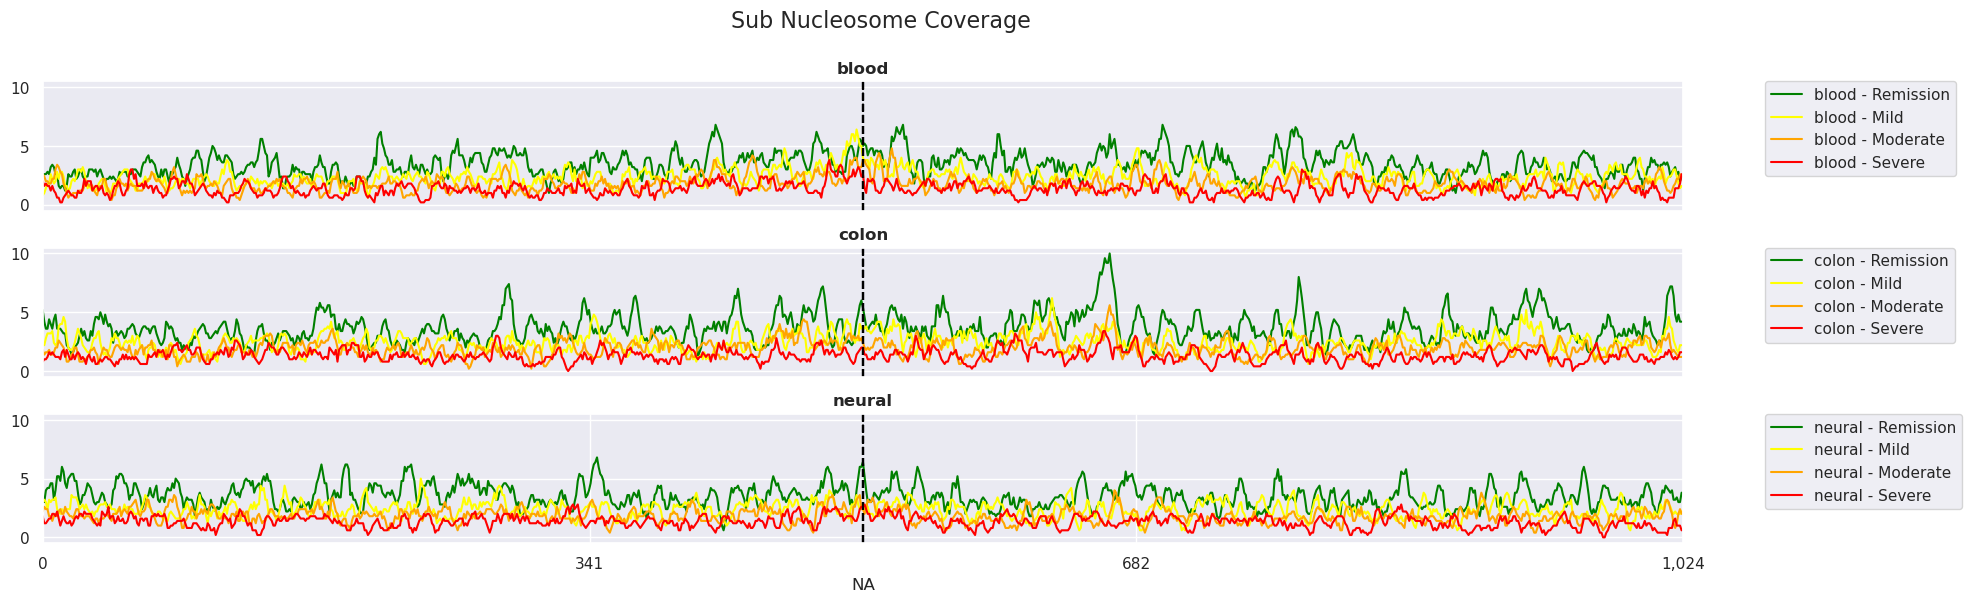

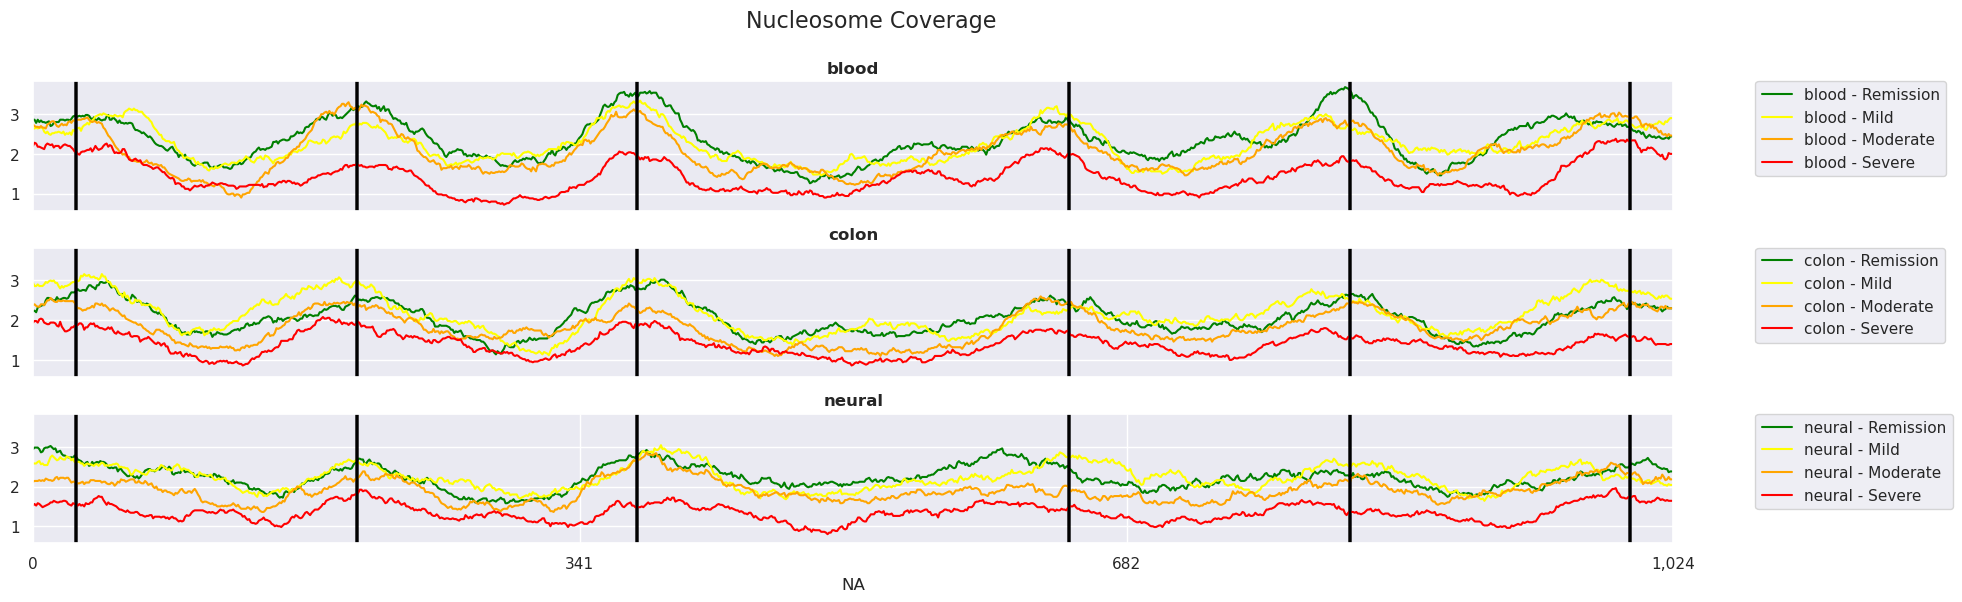

In [20]:
first_nuc=135
offset=175

for fl_normalize in [True, False]:
    all_sub_tracks = Tracks()
    all_nuc_tracks = Tracks()

    for cell_type_label in ['blood', 'colon', 'neural']: # , ,  'neural', 'all']:
        sub_nuc_tracks = []
        nuc_tracks = []
        for severity in severities:
            fa = fa_from_rdf_and_severity(severity, ctcf_rdf.query(f"cell_type == @cell_type_label"), region_size=1024, downsample_size=1500, fl_normalize=fl_normalize, max_num_samples=3)
            sub_nuc_tracks.append(
                CoverageTrack(fa, fa.plot_region, 
                              coverage_type='midpoint', fraction=(40, 60), smooth_window=5, 
                              n_boot_coverage=0,
                              ylim=(None, None),
                              vlines=[VLine(x=512, linestyle='dashed', alpha=0.2, linewidth=0.3)],
                              name=f'{cell_type_label} - {severity}',
                              color=color_mapping[severity],
                ))

            nuc_tracks.append(
                CoverageTrack(fa, fa.plot_region, 
                              coverage_type='midpoint', fraction=(110, 500), smooth_window=50, 
                              n_boot_coverage=0,
                              ylim=None, #  ylim=(2.5, 7.5),
                              vlines=[VLine(x=512+x) for x in (-first_nuc-2*offset, -first_nuc-offset, -first_nuc, first_nuc, first_nuc+offset, first_nuc+2*offset)], 
                              name=f'{cell_type_label} - {severity}',
                              color=color_mapping[severity],
                ))

        sub_nuc_track = sum(sub_nuc_tracks)
        sub_nuc_track.name = cell_type_label
        nuc_track = sum(nuc_tracks)
        nuc_track.name = cell_type_label

        all_sub_tracks.append(sub_nuc_track)
        all_nuc_tracks.append(nuc_track)

    all_sub_tracks.plot(title=f"Sub Nucleosome Coverage{' (Fragment Length Normalized)' if fl_normalize else ''}", sharey=True)
    all_nuc_tracks.plot(title=f"Nucleosome Coverage{' (Fragment Length Normalized)' if fl_normalize else ''}", sharey=True)

#make_tracks(fm_from_regions_mask_and_severity('Remission', only_blood_mask)) # .plot(title='Blood -- Remission')
#make_tracks(fm_from_regions_mask_and_severity('Mild', only_blood_mask)) # .plot(title='Blood -- Mild')
#make_tracks(fm_from_regions_mask_and_severity('Moderate', only_blood_mask)) # .plot(title='Blood -- Moderate')
#make_tracks(fm_from_regions_mask_and_severity('Severe', only_blood_mask)).plot(title='Blood -- Severe')

# TSS Sites

In [13]:
from ravel.constants import REPO_DIR
from ravel.bio.features import load_tss_s_df, load_gene_expression_df
from ravel.public_data_resources.roadmap import CELL_ANATOMY_TO_CELL_EID

In [14]:
tss_s = load_tss_s_df(ref='hg38')
tss_s

,contig,start,stop,id,score,strand,ens_id,num_tss_in_gene,pk_tpm,peakiness
0,chr20,50958528,50958529,ENSG00000000419.12_pk1,1000,-,ENSG00000000419,1,121.79,0.7301
1,chr1,169893923,169893924,ENSG00000000457.13_pk1,1000,-,ENSG00000000457,1,16.47,0.3748
2,chr1,169795042,169795043,ENSG00000000460.16_pk1,1000,+,ENSG00000000460,1,20.47,0.2621
3,chr1,196652051,196652052,ENSG00000000971.15_pk1,1000,+,ENSG00000000971,1,145.20,0.8823
4,chr6,53545097,53545098,ENSG00000001084.10_pk1,1000,-,ENSG00000001084,1,17.27,0.9693
...,...,...,...,...,...,...,...,...,...,...
18272,chr18,73473,73474,ENSG00000282965.1_pk1,1000,-,ENSG00000282965,1,4.53,0.3139
18273,chr7,150405799,150405800,ENSG00000283013.1_pk1,1000,+,ENSG00000283013,1,1.53,0.1900
18274,chr4,119454625,119454626,ENSG00000283050.1_pk1,1000,-,ENSG00000283050,1,20.06,0.3425
18275,chr20,22685459,22685460,ENSG00000283072.1_pk1,1000,+,ENSG00000283072,1,2.86,0.5813


In [15]:
gene_expression = load_gene_expression_df(ref='hg38').set_index("ens_id")
gene_expression

,ENC1,ENC2,ENC3,ENC4,ENC5,ENC6,ENC7,ENC8,ENC9,ENC10,...,E114,E116,E117,E118,E119,E120,E122,E123,E127,E128
ens_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,47.45,26.19,0.31,0.18,3.41,1.25,5.71,3.87,2.74,4.16,...,37.989,0.038,42.639,49.983,11.554,11.847,43.723,0.267,13.758,15.818
ENSG00000000005,0.04,0.00,0.00,0.00,0.09,0.23,0.00,0.00,0.00,0.00,...,0.000,0.000,0.000,0.000,0.000,0.018,0.000,0.006,0.000,0.000
ENSG00000000419,179.87,154.74,24.58,20.34,4.21,1.64,16.48,13.09,12.21,8.39,...,52.215,79.197,107.098,62.811,42.386,54.869,16.652,73.719,56.578,56.371
ENSG00000000457,8.15,7.69,1.86,2.30,2.32,0.53,0.56,0.46,0.36,0.56,...,4.829,11.082,8.814,2.646,2.483,2.527,2.549,7.651,4.967,3.714
ENSG00000000460,26.32,18.98,1.22,1.18,0.92,0.32,3.59,2.61,1.82,3.41,...,8.001,13.743,25.369,3.373,4.646,2.179,4.099,22.103,3.290,2.491
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000259667,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.000,0.000,0.032,0.000,0.000,0.000,0.006,0.000
ENSG00000259718,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
ENSG00000259741,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,74.923,22.036,23.527,16.770,25.595,57.260,15.039,8.164,31.558,57.093


In [16]:
from itertools import chain
gi_cell_eids = sorted(x for x in set(chain(*[CELL_ANATOMY_TO_CELL_EID[x] for x in ['gi_duodenum', 'gi_colon', 'gi_rectum', 'gi_stomach', 'gi_intestine', 'gi_esophagus']])) if x in gene_expression.columns)
blood_cell_eids = sorted(x for x in CELL_ANATOMY_TO_CELL_EID['blood'] if x in gene_expression.columns)

gi_cell_eids, blood_cell_eids

(['E079', 'E094', 'E106', 'E109'],
 ['E037', 'E038', 'E047', 'E050', 'E062', 'E116', 'E123'])

# TSS Analysis

In [17]:
def get_labeled_tss_s():
    filtered_tss_s = tss_s.query("num_tss_in_gene == 1").merge_gene_expression(gene_expression).copy()

    blood_labels = filtered_tss_s.set_binary_label_by_thresholds(
        blood_cell_eids[6],
        on_threshold=25,
        off_threshold=0.01,
        drop_unlabeled_records=False,
    )['label'].rename('blood_label')

    gi_labels = filtered_tss_s.set_binary_label_by_thresholds(
        gi_cell_eids[:1],
        on_threshold=25,
        off_threshold=0.01,
        drop_unlabeled_records=False,
    )['label'].rename('gi_label')


    filtered_tss_s.loc[:, 'cell_type'] = None
    filtered_tss_s.loc[(gi_labels == 1) & (blood_labels == 1), 'cell_type'] = 'all'
    filtered_tss_s.loc[(gi_labels == 1) & (blood_labels == 0), 'cell_type'] = 'gi'
    filtered_tss_s.loc[(gi_labels == 0) & (blood_labels == 1), 'cell_type'] = 'blood'
    filtered_tss_s.loc[(gi_labels == 0) & (blood_labels == 0), 'cell_type'] = 'none'

    filtered_tss_s['gene_id'] = filtered_tss_s.id.str.extract('(ENSG\d+)\..+')

    filtered_tss_s = filtered_tss_s.dropna().reset_index(drop=True)
    
    return filtered_tss_s

In [531]:
filtered_tss_s = get_labeled_tss_s()
filtered_tss_s.cell_type.value_counts()

[autoreload of ravel.fragment_array failed: Traceback (most recent call last):
  File "/home/nboley/miniconda3/envs/ravel/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 257, in check
    superreload(m, reload, self.old_objects)
  File "/home/nboley/miniconda3/envs/ravel/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 480, in superreload
    update_generic(old_obj, new_obj)
  File "/home/nboley/miniconda3/envs/ravel/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 377, in update_generic
    update(a, b)
  File "/home/nboley/miniconda3/envs/ravel/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 329, in update_class
    if update_generic(old_obj, new_obj):
  File "/home/nboley/miniconda3/envs/ravel/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 377, in update_generic
    update(a, b)
  File "/home/nboley/miniconda3/envs/ravel/lib/python3.9/site-packages/IPython/extensions/autoreload.py", li

none     1850
all       663
gi         61
blood       8
Name: cell_type, dtype: int64

In [19]:
filtered_tss_s, counts, fragment_stats = make_counts_and_region_stats(filtered_tss_s, sample_ids_to_samples)

  6%|██████████████████                                                                                                                                                                                                                                                                                                                    | 1/18 [00:06<01:42,  6.05s/it]


KeyboardInterrupt: 

In [ ]:
filtered_tss_s.cell_type.value_counts()

In [ ]:
# filtered_tss_s.query("cell_type == 'all'")
fa, fas = fa_from_rdf(filtered_tss_s.query("cell_type == 'all'"), FragmentsH5(sample_ids_to_samples['RD-56167']), region_size=4096, downsample_size=None, fl_normalize=False)

In [ ]:
fa = fa_from_rdf_and_severity('ALL', filtered_tss_s.query("cell_type == 'all'"), region_size=4096*32, fl_normalize=True, max_num_samples=12)

In [ ]:
make_tracks(fa, True, True, True).plot(title="Active TSS's over ALL IBD Samples")

In [ ]:
none_fa = fa_from_rdf_and_severity('ALL', filtered_tss_s.query("cell_type == 'none'"), region_size=4096*32, fl_normalize=True, max_num_samples=12)

In [ ]:
make_tracks(none_fa, True, True, True).plot(title="In-Active TSS's over ALL IBD Samples")

In [ ]:
fa = fa_from_rdf_and_severity('ALL', filtered_tss_s.query("cell_type == 'blood'"), region_size=4096, fl_normalize=True, max_num_samples=12)

In [ ]:
make_tracks(fa, True, True, True).plot(title="Blood TSS's over ALL IBD Samples")

In [ ]:
list(filtered_tss_s.cell_type.unique())

In [ ]:
for cell_type in filtered_tss_s.cell_type.unique():
    make_tracks(fa_from_rdf_and_severity('ALL', filtered_tss_s.query("cell_type == @cell_type").sample(90), region_size=4096, fl_normalize=False, max_num_samples=12), extra_tracks=True).plot(title=f'TSS Expressed in {cell_type.upper()} across All Samples')

# Simulations

In [ ]:
RegionFragmentArray.from_fragments_h5("/scratch/test_samples/SEQRUN48_LIBRARY574.fragments.h5", Region.from_region_str("chr1:91419-91436").resize(1024))

In [ ]:
neg_density = fm_from_regions_mask(only_neural_mask).sum_pooled(1).dense_array.clip(1e-5)
neg_density = neg_density/neg_density.sum()

In [ ]:
pos_density = fm_from_regions_mask(only_blood_mask).sum_pooled(1).dense_array.clip(1e-5)
pos_density = pos_density/pos_density.sum()

In [ ]:
neg_density.ravel()

In [ ]:
from numpy.random import multinomial as sample_multinomial
from scipy.stats import multinomial as multinomal_density
def sample(p, n):
    x = sample_multinomial(n, p.ravel())
    x.resize(p.shape)
    return x

In [ ]:
n = 10000
disease_frac = 0.5
true = disease_frac*pos_density + (1-disease_frac)*neg_density
obs = sample(true, n)

multinomal_density.logpmf(obs.ravel(), obs.sum(), true.ravel())

In [ ]:
true.shape, obs.shape

In [ ]:
import numpy
numpy.random.rand(100)

# Gene Analysis

In [20]:
# use the gencode basic gtf to find all exonic regions 
# filter by: gene_type "protein_coding"
# find all genes by 
# merge all exons by gene
# take the gene end to be the first poly(A) tail (or the nearest end of the transcript)
# save into a region data frame, and attach fragment matrices
# build the coverage plots banded by fragment size
# stich these together, making sure that the fragment midpoint overlaps the exon
# make some plots!!!

In [416]:
%%time
gencode_df = pd.read_table(
    "/scratch/nboley/gencode/gencode.v39.basic.annotation.protein_coding.gff3",
    usecols=[0, 2, 3, 4, 6, 8],
    names=["contig", "element", "start", "stop", "strand", "meta"],
).query("contig not in ['chrM', 'chrY'] and element in ['transcript', 'exon', 'three_prime_UTR', 'five_prime_UTR']")
gencode_df['gene_id'] = gencode_df.meta.str.extract(';gene_id=(ENSG?\d+)\.\d+;')
gencode_df = gencode_df.drop(columns=['meta'])
gencode_df = gencode_df.drop_duplicates()
gencode_df = gencode_df.sort_values(["contig", "start"])

CPU times: user 8.86 s, sys: 376 ms, total: 9.23 s
Wall time: 9.24 s


In [417]:
gencode_df.element.value_counts()

exon               289650
five_prime_UTR      75701
transcript          58797
three_prime_UTR     54810
Name: element, dtype: int64

In [426]:
gencode_df.query("strand == '-'").head()

,contig,element,start,stop,strand,gene_id
13,chr1,transcript,450740,451678,-,ENSG00000284733
14,chr1,exon,450740,451678,-,ENSG00000284733
19,chr1,transcript,685716,686654,-,ENSG00000284662
20,chr1,exon,685716,686654,-,ENSG00000284662
125,chr1,transcript,944203,959256,-,ENSG00000188976


In [418]:
filtered_tss_s = get_labeled_tss_s() # [['gene_id', 'cell_type']]
filtered_tss_s

,contig,start,stop,id,score,strand,ens_id,num_tss_in_gene,pk_tpm,peakiness,...,E118,E119,E120,E122,E123,E127,E128,label,cell_type,gene_id
0,chr20,50958528,50958529,ENSG00000000419.12_pk1,1000,-,ENSG00000000419,1,121.79,0.7301,...,62.811,42.386,54.869,16.652,73.719,56.578,56.371,1,all,ENSG00000000419
1,chr1,196652051,196652052,ENSG00000000971.15_pk1,1000,+,ENSG00000000971,1,145.20,0.8823,...,0.007,0.419,39.724,8.464,41.504,1.348,32.725,1,all,ENSG00000000971
2,chr17,38870053,38870054,ENSG00000002834.17_pk1,1000,+,ENSG00000002834,1,317.87,0.8141,...,70.159,85.268,128.565,144.330,49.802,86.640,143.304,1,all,ENSG00000002834
3,chr7,127588432,127588433,ENSG00000004059.10_pk1,1000,+,ENSG00000004059,1,39.73,0.5661,...,81.860,198.680,89.048,230.688,108.866,124.927,65.374,1,all,ENSG00000004059
4,chr16,23596298,23596299,ENSG00000004779.9_pk1,1000,-,ENSG00000004779,1,88.24,0.4748,...,136.382,62.265,67.906,121.874,175.205,79.225,49.491,1,all,ENSG00000004779
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2577,chr18,73473,73474,ENSG00000282965.1_pk1,1000,-,ENSG00000282965,1,4.53,0.3139,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,none,ENSG00000282965
2578,chr7,150405799,150405800,ENSG00000283013.1_pk1,1000,+,ENSG00000283013,1,1.53,0.1900,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,none,ENSG00000283013
2579,chr4,119454625,119454626,ENSG00000283050.1_pk1,1000,-,ENSG00000283050,1,20.06,0.3425,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,none,ENSG00000283050
2580,chr20,22685459,22685460,ENSG00000283072.1_pk1,1000,+,ENSG00000283072,1,2.86,0.5813,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,none,ENSG00000283072


In [504]:
p_gene_starts_and_stops = filtered_tss_s.query("strand == '+'").set_index('gene_id')[['start', 'cell_type']].rename(columns={'start': 'tss'}).join(gencode_df.set_index('gene_id'), how='inner').query("element == 'transcript'")[['contig', 'tss', 'stop', 'strand', 'cell_type']].groupby(['gene_id']).min().rename(columns={'tss': 'start'})
p_gene_starts_and_stops['stop'] = p_gene_starts_and_stops['start'] + 1024*60
p_gene_starts_and_stops['start'] = p_gene_starts_and_stops['start'] - 4096


m_gene_starts_and_stops = filtered_tss_s.query("strand == '-'").set_index('gene_id')[['start', 'cell_type']].rename(columns={'start': 'tss'}).join(gencode_df.set_index('gene_id'), how='inner').query("element == 'transcript'")[['contig', 'tss', 'start', 'strand', 'cell_type']].groupby(['gene_id']).max().rename(columns={'tss': 'stop'})
m_gene_starts_and_stops['start'] = m_gene_starts_and_stops['stop'] - 1024*60
m_gene_starts_and_stops['stop'] = m_gene_starts_and_stops['stop'] + 4096


In [505]:
gene_starts_and_stops = pd.concat([p_gene_starts_and_stops, m_gene_starts_and_stops]).sort_values(['start', 'stop']).query('start > 0')
gene_starts_and_stops.cell_type.value_counts()

all      663
none     498
gi        61
blood      7
Name: cell_type, dtype: int64

In [506]:
#gene_starts = gencode_df.query("strand == '+' and element == 'five_prime_UTR'")[['gene_id', 'start']].groupby('gene_id').start.max() 
#gene_stops = gencode_df.query("strand == '+' and element == 'three_prime_UTR'")[['gene_id', 'stop']].groupby('gene_id').stop.min()
#gene_starts_and_stops = pd.DataFrame(gene_starts).join(gene_stops, how='inner')
#gene_starts_and_stops = gene_starts_and_stops.join(filtered_tss_s.set_index("gene_id"), how='inner')

In [507]:
?Region

Init signature:
Region(
    chrom: str,
    start: int = None,
    stop: int = None,
    strand: Optional[str] = None,
    ref: str = 'hg38',
    data: dict = None,
) -> None
Docstring:      Region(chrom: str, start: int = None, stop: int = None, strand: Optional[str] = None, ref: str = 'hg38', data: dict = None)
File:           ~/src/Ravel/fbio/region.py
Type:           type
Subclasses:     


In [508]:
%%time

def hstack_fas(fas):
    rv = fas[0]
    for fa in fas[1:]:
        rv = rv.hstack(fa)
    return rv

def get_fas(regions):
    # deal with positive strand
    # exon_grouper = gencode_df.query("strand == '+' and element == 'exon'")[['gene_id', 'contig', 'strand', 'start', 'stop']].groupby('gene_id')
    fas = {}
    for record in tqdm.tqdm(regions.itertuples(), total=regions.shape[0]):
        # gene_exons_df = RegionDataFrame(exon_grouper.get_group(record.Index).query("start >= @record.start and stop <= @record.stop"), ref='hg38')
        # if gene_exons_df.shape[0] == 0: continue
        inner_fas = []
        for frag_h5 in frag_h5s:
            inner_fas.append(RegionFragmentArray.from_fragments_h5(frag_h5, Region(record.contig, record.start, record.stop, record.strand), include_fragment_strand=True, flip_data_to_match_region_strand=True)) 
            # hstack_fas([RegionFragmentArray.from_fragments_h5(frag_h5, r, include_fragment_strand=True, flip_data_to_match_region_strand=True) for r in gene_exons_df.iter_regions()]))
        if len(inner_fas) > 0:
            fas[record.Index] = merge_fragment_arrays(inner_fas)

    return fas

CPU times: user 14 µs, sys: 2 µs, total: 16 µs
Wall time: 17.9 µs


In [509]:
fas = get_fas(gene_starts_and_stops)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1229/1229 [01:39<00:00, 12.40it/s]


In [510]:
df = gene_starts_and_stops.join(pd.Series(fas).rename('fa')).dropna()
df['fa_length'] = [fa.length for fa in df.fa.tolist()]
df['n_fragments'] = [fa.n_fragments for fa in df.fa.tolist()]

In [511]:
df['fa_length'].value_counts()

65536    1229
Name: fa_length, dtype: int64

<AxesSubplot:>

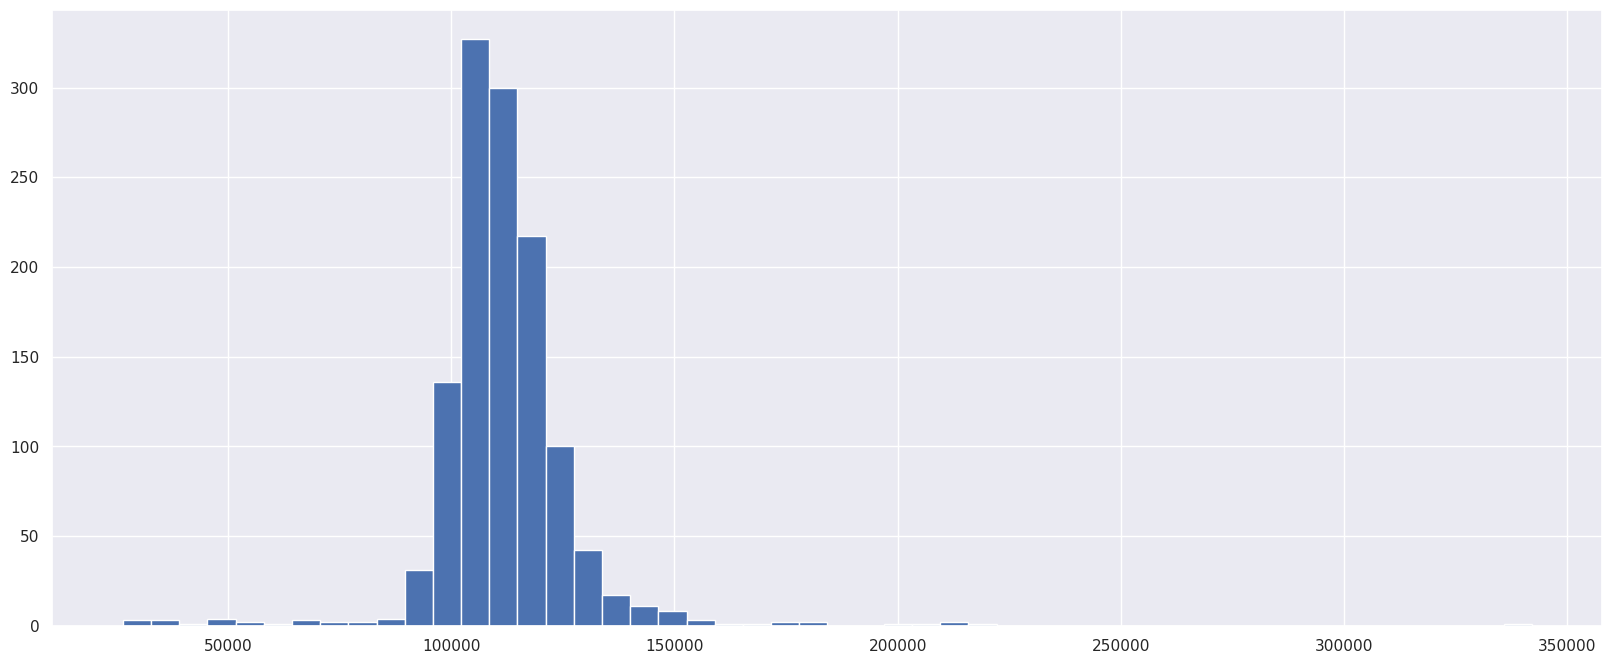

In [512]:
df['n_fragments'].hist(bins=50)

In [513]:
df

,contig,start,stop,strand,cell_type,fa,fa_length,n_fragments
gene_id,,,,,,,,
ENSG00000272602,chr4,49230,114766,+,none,"RegionFragmentArray(n_frags=142597, region=chr...",65536,142597
ENSG00000185627,chr11,232875,298411,+,all,"RegionFragmentArray(n_frags=125994, region=chr...",65536,125994
ENSG00000185885,chr11,309433,374969,+,all,"RegionFragmentArray(n_frags=146204, region=chr...",65536,146204
ENSG00000130731,chr16,574877,640413,-,all,"RegionFragmentArray(n_frags=113901, region=chr...",65536,113901
ENSG00000169020,chr4,612842,678378,-,all,"RegionFragmentArray(n_frags=211291, region=chr...",65536,211291
...,...,...,...,...,...,...,...,...
ENSG00000135902,chr2,232522104,232587640,+,none,"RegionFragmentArray(n_frags=118226, region=chr...",65536,118226
ENSG00000244474,chr2,233714693,233780229,+,gi,"RegionFragmentArray(n_frags=115849, region=chr...",65536,115849
ENSG00000182177,chr2,236202964,236268500,-,none,"RegionFragmentArray(n_frags=122924, region=chr...",65536,122924


In [514]:
import copy
from dataclasses import dataclass, field, replace
from fbio.plot.tracks import CoverageTrack, VLine, Tracks, VplotTrack

# frag_h5 = FragmentsH5("/scratch/karius/finished.fragments.h5") # "/scratch/test_samples/SEQRUN48_LIBRARY577.fragments.h5")
patient_groups = ['Patient Group  1', 'Patient Group  2']
patient_groups = metadata.Cluster.unique().tolist()

severities = ('Remission', 'Mild', 'Moderate', 'Severe')

from fbio.plot.tracks import CoverageTrack, VLine, Tracks, VplotTrack

@dataclass
class CoverageDifferenceTrack(CoverageTrack):
    def _build_coverage(self, *args, **kwargs):
        c1 = copy.deepcopy(self.data).subset_fragment_lengths(self.fraction[0], self.fraction[1]).subset_by_fragment_strand('+').get_midpoint_coverage_array() 
        c2 = copy.deepcopy(self.data).subset_fragment_lengths(self.fraction[0], self.fraction[1]).subset_by_fragment_strand('-').get_midpoint_coverage_array() 
        return c2 - c1

    def _plot(self, ax): 
        super()._plot(ax)
        ax.axhline(0)

def StrandSplitCoverageTrack(fa, *args, **kwargs):
    p1 = CoverageTrack(fa.subset_by_fragment_strand('+'), *args, color='black', **kwargs)
    p1.name = p1.name + ' - Fwd Strand'
    p2 = CoverageTrack(fa.subset_by_fragment_strand('-'), *args, color='green', **kwargs)
    p2.name = p2.name + ' - Rev Strand'
    return p1 + p2

def make_single_strand_tss_tracks(fa, include_vplot=False):
    region_size = fa.shape[1]

    region_size//2+145
    first_nuc=132
    offset=175
    tracks = Tracks()
    if include_vplot:
        tracks.append(VplotTrack(fa, fa.plot_region, sum_pool_by=2))

    for fraction, sm_win in [((40, 60), 300), ((60, 100), 700), ((110, 500), 1500)]:
        for TrackCls in (StrandSplitCoverageTrack, CoverageDifferenceTrack):
            tracks.append(TrackCls(fa, fa.plot_region, coverage_type='midpoint', n_boot_coverage=0, fraction=fraction, smooth_window=sm_win, ylim=(None, None),
                                    vlines=[VLine(x=4096)], 
                                    name=f'{fraction[0]} - {fraction[1]} bp Fraction)'))
    return tracks

In [523]:
fa = merge_fragment_arrays([_ for _ in df.query("cell_type == 'all' and n_fragments > 100000 and n_fragments < 130000").fa.tolist()]).downsampled(40000000) # cell_type == 'all' and 

(<Figure size 2500x1600 with 9 Axes>,
 [<AxesSubplot:title={'center':' 39948861 frags'}>,
  <AxesSubplot:title={'center':'40 - 60 bp Fraction) - Fwd Strand 40 - 60 bp Fraction) - Rev Strand'}>,
  <AxesSubplot:title={'center':'40 - 60 bp Fraction)'}>,
  <AxesSubplot:title={'center':'60 - 100 bp Fraction) - Fwd Strand 60 - 100 bp Fraction) - Rev Strand'}>,
  <AxesSubplot:title={'center':'60 - 100 bp Fraction)'}>,
  <AxesSubplot:title={'center':'110 - 500 bp Fraction) - Fwd Strand 110 - 500 bp Fraction) - Rev Strand'}>,
  <AxesSubplot:title={'center':'110 - 500 bp Fraction)'}, xlabel='NA'>])

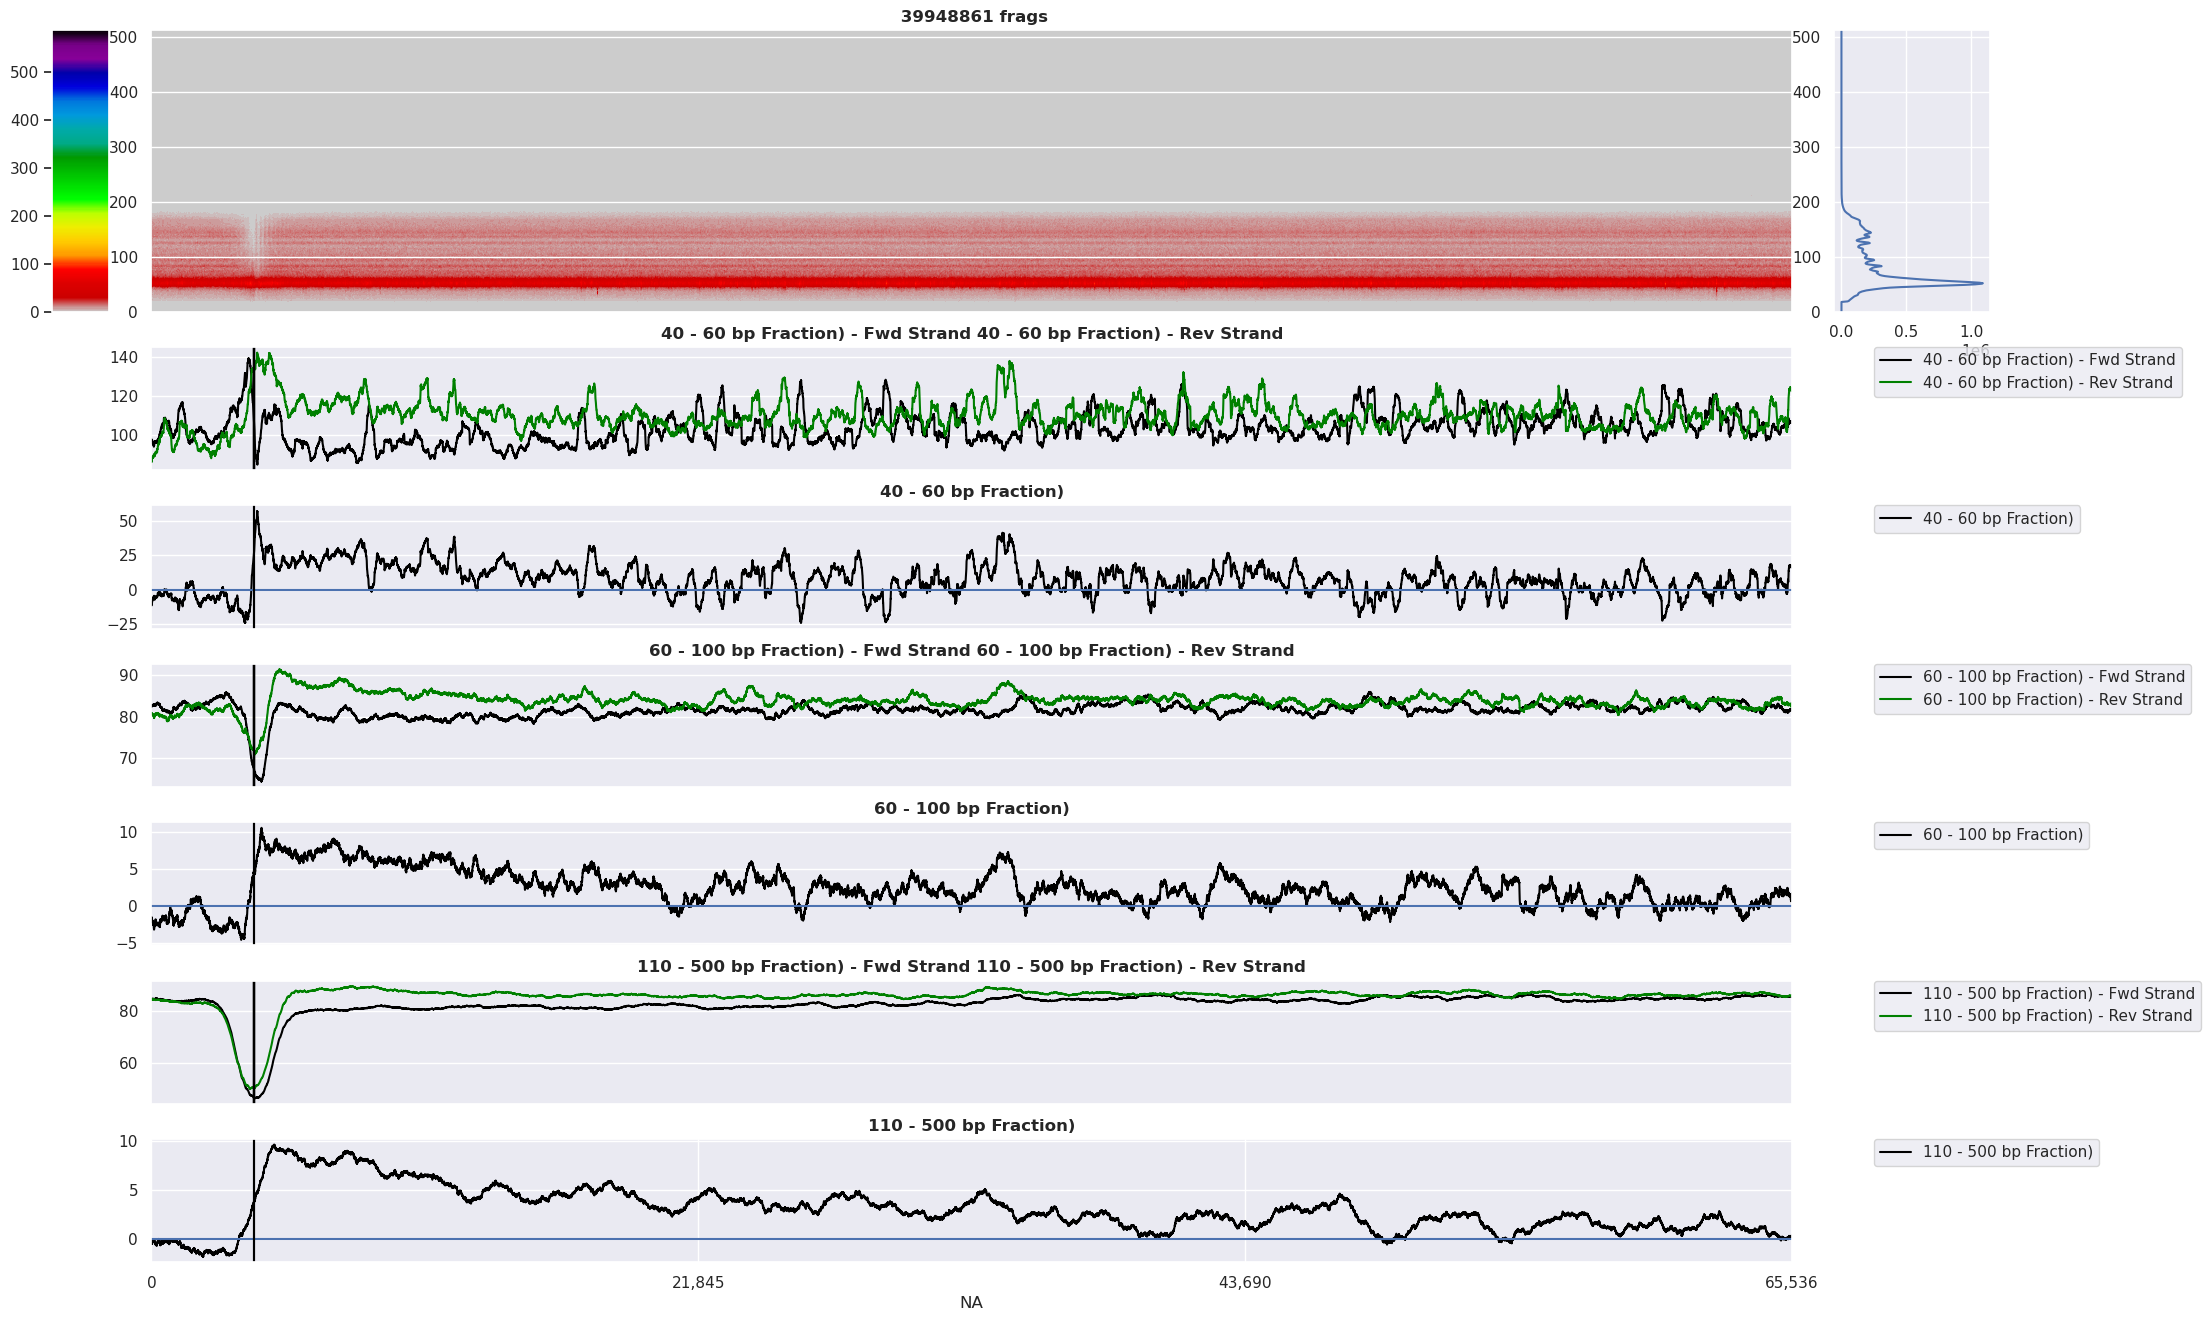

In [524]:
make_single_strand_tss_tracks(fa, True).plot()

(<Figure size 2500x1600 with 9 Axes>,
 [<AxesSubplot:title={'center':' 39951221 frags'}>,
  <AxesSubplot:title={'center':'40 - 60 bp Fraction) - Fwd Strand 40 - 60 bp Fraction) - Rev Strand'}>,
  <AxesSubplot:title={'center':'40 - 60 bp Fraction)'}>,
  <AxesSubplot:title={'center':'60 - 100 bp Fraction) - Fwd Strand 60 - 100 bp Fraction) - Rev Strand'}>,
  <AxesSubplot:title={'center':'60 - 100 bp Fraction)'}>,
  <AxesSubplot:title={'center':'110 - 500 bp Fraction) - Fwd Strand 110 - 500 bp Fraction) - Rev Strand'}>,
  <AxesSubplot:title={'center':'110 - 500 bp Fraction)'}, xlabel='NA'>])

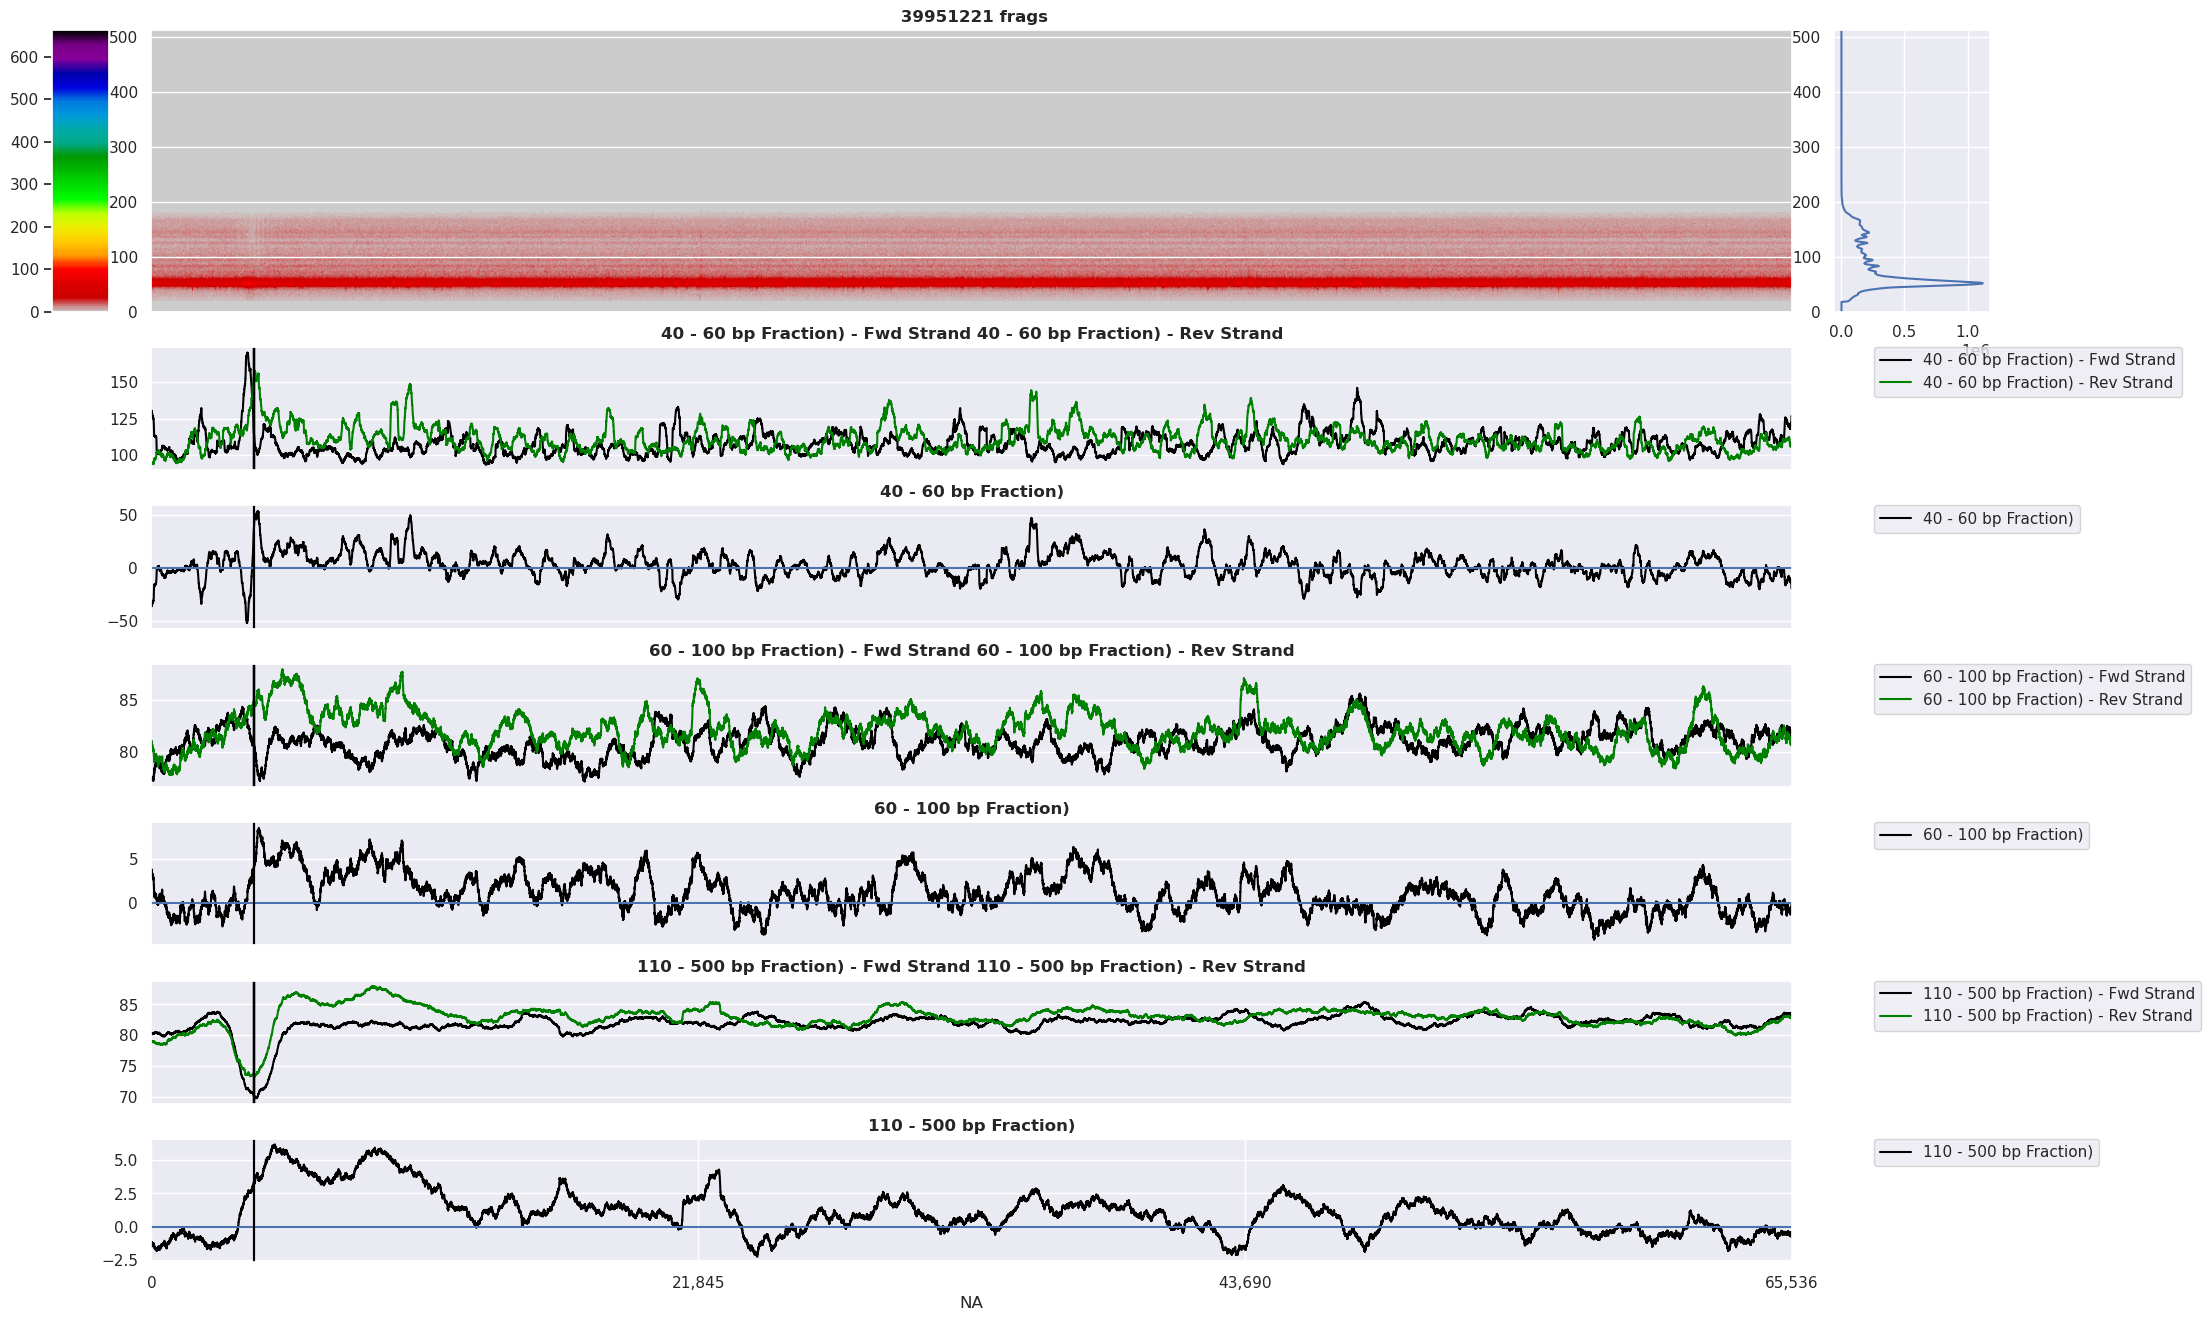

In [525]:
fa = merge_fragment_arrays([_ for _ in df.query("cell_type == 'none' and n_fragments > 100000 and n_fragments < 130000").fa.tolist()]).downsampled(40000000) # cell_type == 'all' and 
make_single_strand_tss_tracks(fa, True).plot()

In [181]:
pd.DataFrame([.truncate(1024)fm.length for fm in fms]).hist(bins=100)

SyntaxError: invalid syntax (1376398094.py, line 1)

(<Figure size 2500x200 with 1 Axes>,
 [<AxesSubplot:title={'center':'coverage'}, xlabel='NA'>])

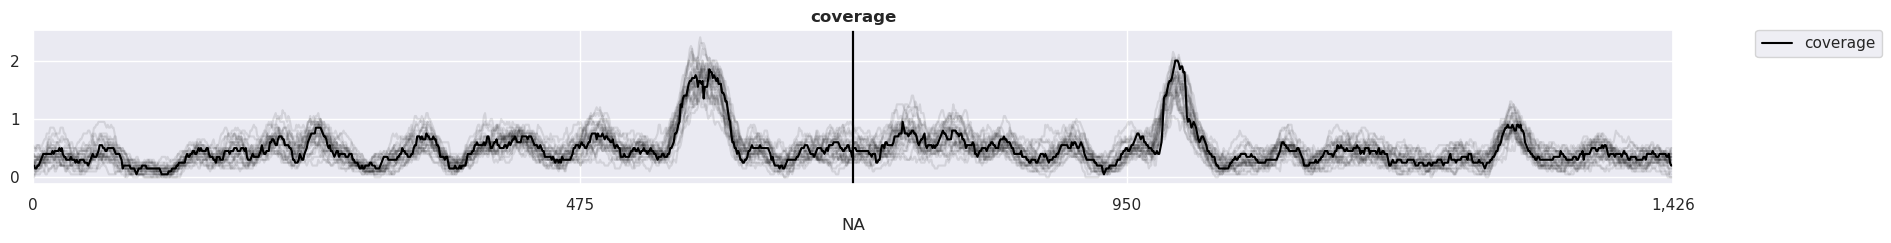

In [423]:
import scipy
tracks = fms[100].make_tracks()
del tracks[0]
tracks.plot()

In [282]:
df.query("strand == '+' and element == 'exon'")

,start,stop
gene_id,,
ENSG00000000005,"[100584936, 100585231, 100593895, 100594261, 1...","[100585066, 100585362, 100594035, 100594362, 1..."
ENSG00000000460,"[169794730, 169795040, 169795043, 169795409, 1...","[169794905, 169795115, 169795213, 169795983, 1..."
ENSG00000000971,"[196652043, 196652045, 196652056, 196672978, 1...","[196652175, 196652175, 196652175, 196673163, 1..."
ENSG00000001167,"[41072974, 41072983, 41079029, 41079029, 41080...","[41073084, 41073084, 41079164, 41079164, 41080..."
ENSG00000001461,"[24415802, 24415803, 24415813, 24415814, 24419...","[24415904, 24415904, 24415904, 24415904, 24419..."
...,...,...
ENSG00000289282,"[31623874, 31624261, 31624450, 31625171, 31625...","[31623909, 31624360, 31624522, 31625314, 31625..."
ENSG00000289325,[66926308],[66926346]
ENSG00000289360,[105040848],[105040925]


In [270]:
df.query("gene_id == 'ENSG00000289281'")

,contig,element,start,stop,strand,gene_id
1228392,chr16,exon,3004132,3004601,+,ENSG00000289281
1228398,chr16,five_prime_UTR,3004132,3004240,+,ENSG00000289281
1228395,chr16,exon,3004603,3004859,+,ENSG00000289281
